In [2]:
# ============================================================
# Cell 1：安装依赖
# ============================================================
# 如果你已经安装过，可以跳过这一格。
# 注意：Jupyter 中第一次安装后，必要时重启 kernel。

!pip install -U tqsdk pandas numpy statsmodels arch matplotlib openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 55.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 92.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 19.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 87.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 95.3 MB/s  0:00:006m0:00:01
  Attempting uninstall: numpy━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/12 [simplejson]
    Found existing installation: numpy 2.3.5━━━━━━━━━━━━━━━━━━  3/12 [simplejson]
    Uninstalling numpy-2.3.5:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/12 [simplejson]
      Successfully uninstalled numpy-2.3.5m━━━━━━━━━━━━━━━━━━━━━━━  5/12 [numpy]]
  Attempting uninstall: pandas0m╺━━━━━━━━━━━━━━━━━━━  6/12 [graphql-core]
    Found existing installation: pandas 2.3.3━━━━━━━━━━━━━━━━━  6/1

In [3]:
# ============================================================
# Cell 2：导入库与基础设置
# ============================================================

import os
import getpass
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqsdk import TqApi, TqAuth

from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

from arch import arch_model

warnings.filterwarnings("ignore")

# Jupyter 显示设置
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

# 输出目录
OUTPUT_DIR = Path("./sr_traditional_volatility_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("输出目录：", OUTPUT_DIR.resolve())

输出目录： /home/zilinm2/sr_traditional_volatility_output


在使用天勤量化之前，默认您已经知晓并同意以下免责条款，如果不同意请立即停止使用：https://www.shinnytech.com/blog/disclaimer/


In [4]:
# ============================================================
# Cell 3：设置研究对象与天勤账号
# ============================================================
# 研究对象：郑商所白糖主力连续合约
# 天勤主连格式通常为：KQ.m@交易所.品种
# 郑商所白糖：CZCE.SR
# 因此白糖主连：KQ.m@CZCE.SR

SYMBOL = "KQ.m@CZCE.SR"
DURATION_SECONDS = 24 * 60 * 60   # 日线
DATA_LENGTH = 8000                # 天勤单次 K 线序列最大长度附近，足够做日线研究

# 建议不要把账号密码写死在代码里。
# 优先读取环境变量；如果没有，就在 notebook 中手动输入。
TQ_USER = os.getenv("TQ_USER")
TQ_PASSWORD = os.getenv("TQ_PASSWORD")

if not TQ_USER:
    TQ_USER = input("请输入天勤账号：")

if not TQ_PASSWORD:
    TQ_PASSWORD = getpass.getpass("请输入天勤密码：")

print("研究标的：", SYMBOL)
print("周期：日线")
print("样本长度请求：", DATA_LENGTH)

请输入天勤账号： 18757528288
请输入天勤密码： ········


研究标的： KQ.m@CZCE.SR
周期：日线
样本长度请求： 8000


In [5]:
# ============================================================
# Cell 4：从天勤获取白糖主连日线数据
# ============================================================
# 核心目标：
# 1. 获取白糖主连日线数据
# 2. 等待 K 线序列 ready
# 3. 复制成普通 pandas DataFrame
# 4. 关闭 api

api = TqApi(auth=TqAuth(TQ_USER, TQ_PASSWORD))

klines = api.get_kline_serial(
    SYMBOL,
    duration_seconds=DURATION_SECONDS,
    data_length=DATA_LENGTH
)

# 等待序列准备完成
# TqSdk 行情对象是引用，需要 wait_update 推进更新。
while not api.is_serial_ready(klines):
    api.wait_update()

raw = klines.copy()

api.close()

print("原始数据行数：", len(raw))
raw.head()

2026-06-17 11:01:16 -     INFO - 通知 : 与 wss://free-api.shinnytech.com/t/nfmd/front/mobile 的网络连接已建立
原始数据行数： 8000


,datetime,id,open,high,low,close,volume,open_oi,close_oi,symbol,duration
0,0.000000,"-5,463.000000",NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,KQ.m@CZCE.SR,86400
1,0.000000,"-5,462.000000",NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,KQ.m@CZCE.SR,86400
2,0.000000,"-5,461.000000",NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,KQ.m@CZCE.SR,86400
3,0.000000,"-5,460.000000",NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,KQ.m@CZCE.SR,86400
4,0.000000,"-5,459.000000",NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,KQ.m@CZCE.SR,86400


In [6]:
# ============================================================
# Cell 5：数据清洗与字段整理
# ============================================================
# 天勤 K 线 datetime 通常为纳秒时间戳。
# 这里转换成 pandas datetime，并保留传统分析需要的核心字段。

df = raw.copy()

# datetime 转换
df["datetime"] = pd.to_datetime(df["datetime"], unit="ns")

# 按时间排序
df = df.sort_values("datetime").reset_index(drop=True)

# 保留核心字段
keep_cols = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "open_oi",
    "close_oi"
]

df = df[keep_cols].copy()

# 清洗无效价格
df = df.dropna(subset=["close"])
df = df[df["close"] > 0].reset_index(drop=True)

# 增加日期字段，方便后续展示
df["date"] = df["datetime"].dt.date

print("清洗后数据行数：", len(df))
print("起始日期：", df["datetime"].min())
print("结束日期：", df["datetime"].max())

df.head()

清洗后数据行数： 2537
起始日期： 2016-01-04 16:00:00
结束日期： 2026-06-16 16:00:00


,datetime,open,high,low,close,volume,open_oi,close_oi,date
0,2016-01-04 16:00:00,"5,607.000000","5,621.000000","5,579.000000","5,599.000000","513,246.000000",0.000000,"489,626.000000",2016-01-04
1,2016-01-05 16:00:00,"5,593.000000","5,600.000000","5,530.000000","5,545.000000","677,626.000000","489,626.000000","471,402.000000",2016-01-05
2,2016-01-06 16:00:00,"5,539.000000","5,573.000000","5,492.000000","5,530.000000","720,487.000000","471,402.000000","455,284.000000",2016-01-06
3,2016-01-07 16:00:00,"5,549.000000","5,578.000000","5,526.000000","5,559.000000","560,286.000000","455,284.000000","464,013.000000",2016-01-07
4,2016-01-10 16:00:00,"5,573.000000","5,576.000000","5,465.000000","5,470.000000","762,531.000000","464,013.000000","475,425.000000",2016-01-10


In [7]:
# ============================================================
# Cell 6：计算对数收益率
# ============================================================
# 传统 GARCH 类模型一般不直接建模价格，而是建模收益率。
# 对数收益率：
# ret_t = ln(close_t / close_{t-1})
#
# arch 包通常建议收益率不要太小，因此这里额外构造 ret_pct：
# ret_pct = ret * 100
# 表示百分比收益率，例如 0.01 代表 0.01%，不是 1%。

df["log_price"] = np.log(df["close"])
df["ret"] = df["log_price"].diff()
df["ret_pct"] = df["ret"] * 100

# 去掉第一行收益率缺失
df = df.dropna(subset=["ret", "ret_pct"]).reset_index(drop=True)

# 简单换月 / 异常收益过滤提示：
# 主连换月可能出现异常跳点，这里先不强行删除，只标记极端收益。
# 后续可以根据 abs(ret_pct) 分位数或交易所涨跌停制度进一步处理。
df["abs_ret_pct"] = df["ret_pct"].abs()
extreme_cut = df["abs_ret_pct"].quantile(0.999)
df["is_extreme_ret"] = df["abs_ret_pct"] > extreme_cut

print("收益率样本行数：", len(df))
print("极端收益阈值 99.9% 分位：", extreme_cut)

df[["datetime", "close", "ret", "ret_pct", "is_extreme_ret"]].head()

收益率样本行数： 2536
极端收益阈值 99.9% 分位： 4.403148080191152


,datetime,close,ret,ret_pct,is_extreme_ret
0,2016-01-05 16:00:00,"5,545.000000",-0.009691,-0.969139,False
1,2016-01-06 16:00:00,"5,530.000000",-0.002709,-0.270881,False
2,2016-01-07 16:00:00,"5,559.000000",0.005230,0.523042,False
3,2016-01-10 16:00:00,"5,470.000000",-0.016140,-1.613962,False
4,2016-01-11 16:00:00,"5,451.000000",-0.003480,-0.347954,False


In [8]:
# ============================================================
# Cell 7：保存基础数据
# ============================================================

price_file = OUTPUT_DIR / "sr_main_daily_cleaned.csv"
df.to_csv(price_file, index=False, encoding="utf-8-sig")

print("已保存：", price_file)

已保存： sr_traditional_volatility_output/sr_main_daily_cleaned.csv


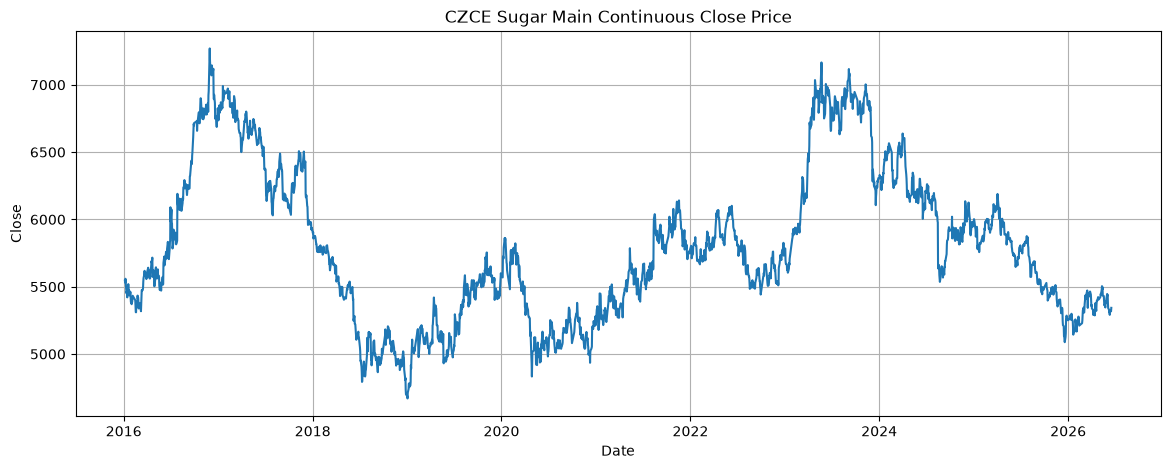

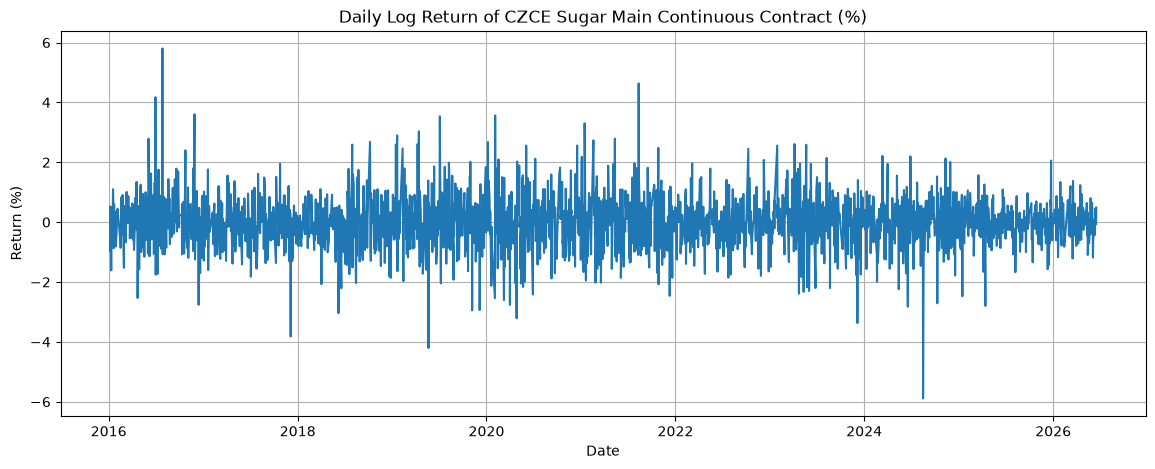

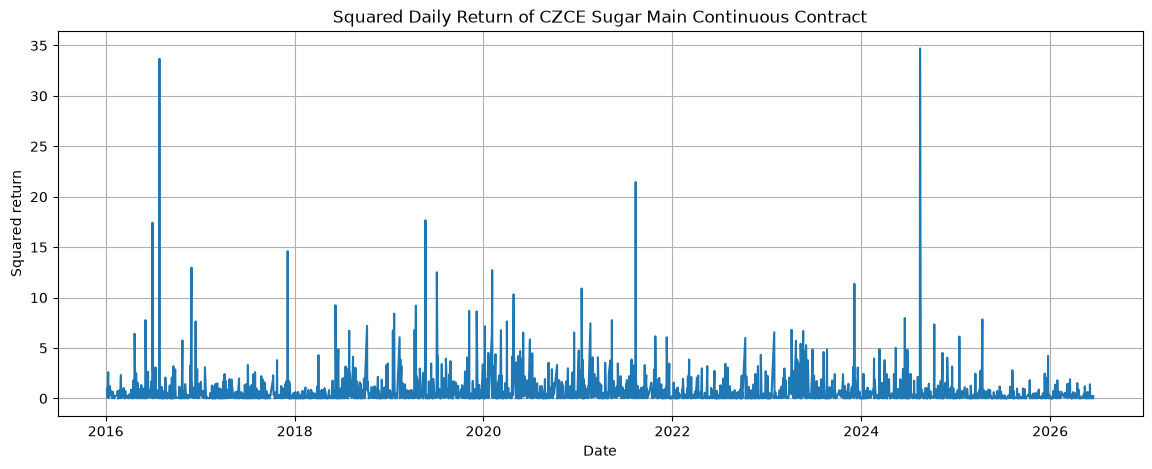

In [9]:
# ============================================================
# Cell 8：画价格、收益率、平方收益率
# ============================================================
# 目的：
# 1. 看价格是否有明显趋势和非平稳性
# 2. 看收益率是否围绕 0 波动
# 3. 看收益率平方是否存在波动率聚集

plt.figure(figsize=(14, 5))
plt.plot(df["datetime"], df["close"])
plt.title("CZCE Sugar Main Continuous Close Price")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df["datetime"], df["ret_pct"])
plt.title("Daily Log Return of CZCE Sugar Main Continuous Contract (%)")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df["datetime"], df["ret_pct"] ** 2)
plt.title("Squared Daily Return of CZCE Sugar Main Continuous Contract")
plt.xlabel("Date")
plt.ylabel("Squared return")
plt.grid(True)
plt.show()

In [10]:
# ============================================================
# Cell 9：描述性统计
# ============================================================
# 目的：
# 观察白糖主连收益率的均值、波动、偏度、峰度、极端涨跌。
# 商品期货收益率一般会有尖峰厚尾，因此 Student-t GARCH 通常比 Normal GARCH 更值得比较。

ret = df["ret_pct"].dropna()

desc = pd.DataFrame({
    "metric": [
        "count",
        "mean",
        "std",
        "min",
        "1%",
        "5%",
        "25%",
        "50%",
        "75%",
        "95%",
        "99%",
        "max",
        "skew",
        "kurtosis"
    ],
    "value": [
        ret.count(),
        ret.mean(),
        ret.std(),
        ret.min(),
        ret.quantile(0.01),
        ret.quantile(0.05),
        ret.quantile(0.25),
        ret.quantile(0.50),
        ret.quantile(0.75),
        ret.quantile(0.95),
        ret.quantile(0.99),
        ret.max(),
        ret.skew(),
        ret.kurtosis()
    ]
})

desc_file = OUTPUT_DIR / "01_return_descriptive_stats.csv"
desc.to_csv(desc_file, index=False, encoding="utf-8-sig")

desc

,metric,value
0,count,"2,536.000000"
1,mean,-0.001845
2,std,0.840685
3,min,-5.891147
4,1%,-2.191571
5,5%,-1.340332
6,25%,-0.442993
7,50%,0.017316
8,75%,0.443952
9,95%,1.304068


In [11]:
# ============================================================
# Cell 10：ADF 平稳性检验函数
# ============================================================
# ADF 检验：
# H0：存在单位根，序列非平稳
# H1：不存在单位根，序列平稳
#
# 传统预期：
# 价格 / log_price：通常不能拒绝 H0，可能非平稳
# 收益率 / ret_pct：通常拒绝 H0，收益率平稳

def run_adf_test(series, name):
    series = pd.Series(series).dropna()
    result = adfuller(series, autolag="AIC")
    
    out = {
        "series": name,
        "adf_stat": result[0],
        "p_value": result[1],
        "used_lag": result[2],
        "n_obs": result[3],
        "critical_1%": result[4].get("1%"),
        "critical_5%": result[4].get("5%"),
        "critical_10%": result[4].get("10%"),
        "decision_5pct": "stationary" if result[1] < 0.05 else "non_stationary_or_inconclusive"
    }
    return out

adf_results = pd.DataFrame([
    run_adf_test(df["log_price"], "log_price"),
    run_adf_test(df["ret_pct"], "ret_pct")
])

adf_file = OUTPUT_DIR / "02_adf_tests.csv"
adf_results.to_csv(adf_file, index=False, encoding="utf-8-sig")

adf_results

,series,adf_stat,p_value,used_lag,n_obs,critical_1%,critical_5%,critical_10%,decision_5pct
0,log_price,-2.111064,0.240089,1,2534,-3.432933,-2.862681,-2.567378,non_stationary_or_inconclusive
1,ret_pct,-22.040565,0.000000,5,2530,-3.432937,-2.862683,-2.567379,stationary


In [13]:
# ============================================================
# Cell 11：Ljung-Box 自相关检验函数
# ============================================================
# Ljung-Box 检验：
# H0：前 m 阶自相关整体为 0
# H1：至少存在某些阶数的自相关
#
# 对 ret_pct 做检验：
# 检查收益率方向是否有自相关。
#
# 对 ret_pct^2 做检验：
# 检查平方收益率是否有自相关，也就是是否存在波动率聚集。

def run_ljungbox(series, name, lags=(5, 10, 20, 30)):
    series = pd.Series(series).dropna()
    lb = acorr_ljungbox(series, lags=list(lags), return_df=True)
    lb = lb.reset_index().rename(columns={"index": "lag"})
    lb.insert(0, "series", name)
    lb["decision_5pct"] = np.where(
        lb["lb_pvalue"] < 0.05,
        "reject_no_autocorr",
        "fail_to_reject_no_autocorr"
    )
    return lb

lb_ret = run_ljungbox(df["ret_pct"], "ret_pct")
lb_ret_sq = run_ljungbox(df["ret_pct"] ** 2, "ret_pct_squared")

lb_raw = pd.concat([lb_ret, lb_ret_sq], ignore_index=True)

lb_file = OUTPUT_DIR / "03_ljungbox_raw_returns.csv"
lb_raw.to_csv(lb_file, index=False, encoding="utf-8-sig")

lb_raw

,series,lag,lb_stat,lb_pvalue,decision_5pct
0,ret_pct,5,11.647145,0.039956,reject_no_autocorr
1,ret_pct,10,15.143446,0.126919,fail_to_reject_no_autocorr
2,ret_pct,20,27.760724,0.115186,fail_to_reject_no_autocorr
3,ret_pct,30,33.710639,0.292548,fail_to_reject_no_autocorr
4,ret_pct_squared,5,7.587000,0.180514,fail_to_reject_no_autocorr
5,ret_pct_squared,10,9.658954,0.470906,fail_to_reject_no_autocorr
6,ret_pct_squared,20,48.220010,0.000396,reject_no_autocorr
7,ret_pct_squared,30,56.723542,0.002253,reject_no_autocorr


In [14]:
# ============================================================
# Cell 12：ARCH-LM 检验函数
# ============================================================
# ARCH-LM 检验：
# H0：不存在 ARCH 效应
# H1：存在 ARCH 效应
#
# 如果收益率序列 ARCH-LM 显著，说明存在条件异方差，
# 也就是进入 ARCH / GARCH 建模有统计基础。

def run_arch_lm(series, name, nlags=10):
    series = pd.Series(series).dropna()
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(series, nlags=nlags)
    return {
        "series": name,
        "nlags": nlags,
        "lm_stat": lm_stat,
        "lm_pvalue": lm_pvalue,
        "f_stat": f_stat,
        "f_pvalue": f_pvalue,
        "decision_5pct": "arch_effect_exists" if lm_pvalue < 0.05 else "no_arch_effect_detected"
    }

arch_lm_raw = pd.DataFrame([
    run_arch_lm(df["ret_pct"], "ret_pct", nlags=5),
    run_arch_lm(df["ret_pct"], "ret_pct", nlags=10),
    run_arch_lm(df["ret_pct"], "ret_pct", nlags=20)
])

arch_lm_file = OUTPUT_DIR / "04_arch_lm_raw_returns.csv"
arch_lm_raw.to_csv(arch_lm_file, index=False, encoding="utf-8-sig")

arch_lm_raw

,series,nlags,lm_stat,lm_pvalue,f_stat,f_pvalue,decision_5pct
0,ret_pct,5,7.478164,0.187437,1.496509,0.187582,no_arch_effect_detected
1,ret_pct,10,9.281863,0.505579,0.927553,0.506389,no_arch_effect_detected
2,ret_pct,20,42.979811,0.002057,2.168090,0.001957,arch_effect_exists


In [15]:
# ============================================================
# Cell 13：传统建模前的初步判断
# ============================================================
# 这一格把前面的检验结果转换成文字判断。
#
# 传统逻辑：
# 1. 收益率平稳；
# 2. 收益率平方存在自相关；
# 3. ARCH-LM 显著；
# 则说明白糖主连收益率适合进入 GARCH 类波动率建模。

adf_ret_p = adf_results.loc[adf_results["series"] == "ret_pct", "p_value"].iloc[0]
lb_sq_p10 = lb_raw[(lb_raw["series"] == "ret_pct_squared") & (lb_raw["lag"] == 10)]["lb_pvalue"].iloc[0]
arch_p10 = arch_lm_raw[arch_lm_raw["nlags"] == 10]["lm_pvalue"].iloc[0]

print("========== 传统建模前判断 ==========")
print(f"ADF(ret_pct) p-value        = {adf_ret_p:.6f}")
print(f"Ljung-Box(ret_pct^2, lag10) = {lb_sq_p10:.6f}")
print(f"ARCH-LM(ret_pct, lag10)     = {arch_p10:.6f}")

if adf_ret_p < 0.05:
    print("1. 收益率通过平稳性检验：可以对收益率建模。")
else:
    print("1. 收益率未通过平稳性检验：需要谨慎检查数据。")

if lb_sq_p10 < 0.05:
    print("2. 平方收益率存在显著自相关：存在波动率聚集。")
else:
    print("2. 平方收益率未发现显著自相关：波动率聚集不强。")

if arch_p10 < 0.05:
    print("3. ARCH-LM 显著：存在条件异方差，适合 GARCH 类模型。")
else:
    print("3. ARCH-LM 不显著：GARCH 必要性下降。")

========== 传统建模前判断 ==========
ADF(ret_pct) p-value        = 0.000000
Ljung-Box(ret_pct^2, lag10) = 0.470906
ARCH-LM(ret_pct, lag10)     = 0.505579
1. 收益率通过平稳性检验：可以对收益率建模。
2. 平方收益率未发现显著自相关：波动率聚集不强。
3. ARCH-LM 不显著：GARCH 必要性下降。


In [17]:
# ============================================================
# Cell 14：定义 GARCH 类模型估计函数
# ============================================================
# 传统模型组：
#
# 1. ARCH(5)-t
#    最基础的 ARCH 模型，用过去多个残差平方解释今天方差。
#
# 2. GARCH(1,1)-Normal
#    最经典基准模型，但正态分布可能低估厚尾。
#
# 3. GARCH(1,1)-Student-t
#    商品期货收益率通常厚尾，因此这个模型通常更稳健。
#
# 4. EGARCH(1,1)-Student-t
#    用于处理非对称波动，且方差天然为正。
#
# 5. GJR-GARCH(1,1)-Student-t
#    通过 o=1 加入非对称项，检验正负冲击影响是否不同。
#
# 6. AR(1)-GARCH(1,1)-Student-t
#    如果收益率本身存在方向自相关，则加入 AR(1) 均值项。

y = df["ret_pct"].dropna()

def fit_arch_model(model_name, y, mean, vol, p=1, o=0, q=1, dist="normal", lags=None):
    """
    拟合 arch 包中的单变量波动率模型。
    
    参数含义：
    model_name：模型名称，仅用于输出记录
    y         ：收益率序列，建议使用百分比收益率
    mean      ：均值模型，例如 Constant, AR
    vol       ：波动率模型，例如 ARCH, GARCH, EGARCH
    p, o, q   ：波动率模型阶数
    dist      ：残差分布，例如 normal, t
    lags      ：均值方程 AR 滞后阶数；mean='AR' 时使用
    """
    try:
        if mean == "AR":
            am = arch_model(
                y,
                mean=mean,
                lags=lags,
                vol=vol,
                p=p,
                o=o,
                q=q,
                dist=dist,
                rescale=False
            )
        else:
            am = arch_model(
                y,
                mean=mean,
                vol=vol,
                p=p,
                o=o,
                q=q,
                dist=dist,
                rescale=False
            )
        
        res = am.fit(disp="off")
        print(f"{model_name}: fitted successfully")
        return res
    
    except Exception as e:
        print(f"{model_name}: failed -> {e}")
        return None

In [18]:
# ============================================================
# Cell 15：拟合传统模型组
# ============================================================

models = {}

# 1. ARCH(5)-Student-t
models["ARCH5_t"] = fit_arch_model(
    model_name="ARCH5_t",
    y=y,
    mean="Constant",
    vol="ARCH",
    p=5,
    o=0,
    q=0,
    dist="t"
)

# 2. GARCH(1,1)-Normal
models["GARCH11_Normal"] = fit_arch_model(
    model_name="GARCH11_Normal",
    y=y,
    mean="Constant",
    vol="GARCH",
    p=1,
    o=0,
    q=1,
    dist="normal"
)

# 3. GARCH(1,1)-Student-t
models["GARCH11_t"] = fit_arch_model(
    model_name="GARCH11_t",
    y=y,
    mean="Constant",
    vol="GARCH",
    p=1,
    o=0,
    q=1,
    dist="t"
)

# 4. EGARCH(1,1)-Student-t
# 这里设置 o=1，用于捕捉非对称项。
models["EGARCH11_t"] = fit_arch_model(
    model_name="EGARCH11_t",
    y=y,
    mean="Constant",
    vol="EGARCH",
    p=1,
    o=1,
    q=1,
    dist="t"
)

# 5. GJR-GARCH(1,1)-Student-t
# arch 包中 vol='GARCH', o=1 表示加入非对称项，通常对应 GJR-GARCH。
models["GJR_GARCH11_t"] = fit_arch_model(
    model_name="GJR_GARCH11_t",
    y=y,
    mean="Constant",
    vol="GARCH",
    p=1,
    o=1,
    q=1,
    dist="t"
)

# 6. AR(1)-GARCH(1,1)-Student-t
# 如果 Ljung-Box on ret 显著，说明收益率方向可能有自相关，可以加入 AR(1) 均值项。
models["AR1_GARCH11_t"] = fit_arch_model(
    model_name="AR1_GARCH11_t",
    y=y,
    mean="AR",
    lags=1,
    vol="GARCH",
    p=1,
    o=0,
    q=1,
    dist="t"
)

# 删除拟合失败的模型
models = {k: v for k, v in models.items() if v is not None}

print("成功拟合模型：")
list(models.keys())

ARCH5_t: fitted successfully
GARCH11_Normal: fitted successfully
GARCH11_t: fitted successfully
EGARCH11_t: fitted successfully
GJR_GARCH11_t: fitted successfully
AR1_GARCH11_t: fitted successfully
成功拟合模型：


['ARCH5_t',
 'GARCH11_Normal',
 'GARCH11_t',
 'EGARCH11_t',
 'GJR_GARCH11_t',
 'AR1_GARCH11_t']

In [19]:
# ============================================================
# Cell 16：保存每个模型的 summary
# ============================================================

summary_dir = OUTPUT_DIR / "model_summaries"
summary_dir.mkdir(exist_ok=True)

for name, res in models.items():
    summary_text = str(res.summary())
    file_path = summary_dir / f"{name}_summary.txt"
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(summary_text)

print("模型摘要已保存到：", summary_dir.resolve())

模型摘要已保存到： /home/zilinm2/sr_traditional_volatility_output/model_summaries


In [24]:
# ============================================================
# Cell 17：提取模型核心参数
# ============================================================
# 目的：
# 把不同模型的 AIC、BIC、核心参数放进同一张表。
#
# 重点参数：
# mu        ：均值项
# omega     ：方差方程常数
# alpha[1]  ：短期冲击项
# beta[1]   ：波动率持续项
# gamma[1]  ：非对称项，EGARCH / GJR 中常见
# nu        ：Student-t 自由度，越低厚尾越强

def get_param(res, key):
    try:
        return res.params.get(key, np.nan)
    except Exception:
        return np.nan

param_rows = []

for name, res in models.items():
    params = res.params
    
    row = {
        "model": name,
        "loglikelihood": res.loglikelihood,
        "aic": res.aic,
        "bic": res.bic,
        "nobs": res.nobs,
        "mu": get_param(res, "mu"),
        "omega": get_param(res, "omega"),
        "alpha[1]": get_param(res, "alpha[1]"),
        "gamma[1]": get_param(res, "gamma[1]"),
        "beta[1]": get_param(res, "beta[1]"),
        "nu": get_param(res, "nu")
    }
    
    # 普通 GARCH 的持续性：alpha + beta
    if not np.isnan(row["alpha[1]"]) and not np.isnan(row["beta[1]"]):
        row["alpha_plus_beta"] = row["alpha[1]"] + row["beta[1]"]
    else:
        row["alpha_plus_beta"] = np.nan
    
    # GJR-GARCH 的近似持续性：alpha + beta + gamma/2
    if not np.isnan(row["alpha[1]"]) and not np.isnan(row["beta[1]"]) and not np.isnan(row["gamma[1]"]):
        row["gjr_persistence_approx"] = row["alpha[1]"] + row["beta[1]"] + 0.5 * row["gamma[1]"]
    else:
        row["gjr_persistence_approx"] = np.nan
    
    param_rows.append(row)

model_params = pd.DataFrame(param_rows).sort_values("aic").reset_index(drop=True)

params_file = OUTPUT_DIR / "05_model_parameters.csv"
model_params.to_csv(params_file, index=False, encoding="utf-8-sig")

model_params

,model,loglikelihood,aic,bic,nobs,mu,omega,alpha[1],gamma[1],beta[1],nu,alpha_plus_beta,gjr_persistence_approx
0,EGARCH11_t,"-2,978.755773","5,969.511547","6,004.541607",2536,0.000002,0.000804,0.057641,0.019412,0.989908,4.497111,1.047549,1.057255
1,AR1_GARCH11_t,"-2,981.464328","5,974.928655","6,009.956349",2535,NaN,0.004005,0.018904,NaN,0.976105,4.456365,0.995009,NaN
2,GJR_GARCH11_t,"-2,981.668054","5,975.336108","6,010.366168",2536,-0.000937,0.005552,0.028719,-0.018915,0.973763,4.476455,1.002482,0.993024
3,GARCH11_t,"-2,984.442729","5,978.885458","6,008.077174",2536,-0.003129,0.003769,0.018924,NaN,0.976385,4.483401,0.995309,NaN
4,ARCH5_t,"-3,004.829230","6,025.658460","6,072.365207",2536,0.003713,0.600816,0.032462,NaN,NaN,4.269752,NaN,NaN
5,GARCH11_Normal,"-3,114.306053","6,236.612105","6,259.965478",2536,-0.014121,0.003684,0.017454,NaN,0.977507,NaN,0.994961,NaN


In [25]:
# ============================================================
# Cell 18：标准化残差诊断函数
# ============================================================
# 模型拟合后，传统诊断的核心不是看原始收益率，
# 而是看标准化残差：
#
# z_t = epsilon_t / sigma_t
#
# 一个好的波动率模型，应该使：
# 1. z_t 没有明显自相关；
# 2. z_t^2 没有明显自相关；
# 3. z_t 没有剩余 ARCH 效应。
#
# 对应检验：
# Ljung-Box on z_t
# Ljung-Box on z_t^2
# ARCH-LM on z_t

def diagnose_standardized_residuals(res, model_name, lags=(5, 10, 20, 30)):
    std_resid = pd.Series(res.std_resid).replace([np.inf, -np.inf], np.nan).dropna()
    std_resid_sq = std_resid ** 2
    
    lb_z = acorr_ljungbox(std_resid, lags=list(lags), return_df=True)
    lb_z2 = acorr_ljungbox(std_resid_sq, lags=list(lags), return_df=True)
    
    # ARCH-LM 常用 lag=10
    arch_lm_10 = het_arch(std_resid, nlags=10)
    
    row = {
        "model": model_name,
        "n_std_resid": len(std_resid),
        "std_resid_mean": std_resid.mean(),
        "std_resid_std": std_resid.std(),
        "std_resid_skew": std_resid.skew(),
        "std_resid_kurtosis": std_resid.kurtosis(),
        "ARCH_LM_lag10_pvalue": arch_lm_10[1]
    }
    
    # 加入各 lag 的 Ljung-Box p-value
    for lag in lags:
        row[f"LB_z_lag{lag}_pvalue"] = lb_z.loc[lag, "lb_pvalue"]
        row[f"LB_z2_lag{lag}_pvalue"] = lb_z2.loc[lag, "lb_pvalue"]
    
    # 传统 5% 标准下的判断
    # 这里用 lag10 和 ARCH-LM lag10 作为主判断。
    lb_z_10 = row["LB_z_lag10_pvalue"]
    lb_z2_10 = row["LB_z2_lag10_pvalue"]
    arch_p = row["ARCH_LM_lag10_pvalue"]
    
    row["mean_equation_pass_lag10"] = lb_z_10 > 0.05
    row["vol_equation_pass_lag10"] = lb_z2_10 > 0.05
    row["arch_lm_pass_lag10"] = arch_p > 0.05
    
    if row["mean_equation_pass_lag10"] and row["vol_equation_pass_lag10"] and row["arch_lm_pass_lag10"]:
        row["traditional_decision"] = "PASS"
    else:
        row["traditional_decision"] = "FAIL_OR_NEEDS_IMPROVEMENT"
    
    return row

In [26]:
# ============================================================
# Cell 19：执行标准化残差诊断
# ============================================================

diag_rows = []

for name, res in models.items():
    diag_rows.append(diagnose_standardized_residuals(res, name))

diagnostics = pd.DataFrame(diag_rows)

# 合并 AIC/BIC 参数表，方便综合比较
model_compare = diagnostics.merge(
    model_params,
    on="model",
    how="left"
)

# 排序：优先看传统诊断通过，其次看 AIC 更低
model_compare = model_compare.sort_values(
    by=["traditional_decision", "aic"],
    ascending=[True, True]
).reset_index(drop=True)

diag_file = OUTPUT_DIR / "06_model_diagnostics.csv"
model_compare.to_csv(diag_file, index=False, encoding="utf-8-sig")

model_compare

,model,n_std_resid,std_resid_mean,std_resid_std,std_resid_skew,std_resid_kurtosis,ARCH_LM_lag10_pvalue,LB_z_lag5_pvalue,LB_z2_lag5_pvalue,LB_z_lag10_pvalue,LB_z2_lag10_pvalue,LB_z_lag20_pvalue,LB_z2_lag20_pvalue,LB_z_lag30_pvalue,LB_z2_lag30_pvalue,mean_equation_pass_lag10,vol_equation_pass_lag10,arch_lm_pass_lag10,traditional_decision,loglikelihood,aic,bic,nobs,mu,omega,alpha[1],gamma[1],beta[1],nu,alpha_plus_beta,gjr_persistence_approx
0,EGARCH11_t,2536,-0.006713,0.990485,-0.143148,3.818970,0.869068,0.140810,0.770292,0.321999,0.862060,0.538420,0.815224,0.796358,0.954347,True,True,True,PASS,"-2,978.755773","5,969.511547","6,004.541607",2536,0.000002,0.000804,0.057641,0.019412,0.989908,4.497111,1.047549,1.057255
1,AR1_GARCH11_t,2535,-0.003384,0.991863,-0.088109,3.814141,0.805507,0.173617,0.723833,0.348248,0.804956,0.549374,0.614400,0.814818,0.828552,True,True,True,PASS,"-2,981.464328","5,974.928655","6,009.956349",2535,NaN,0.004005,0.018904,NaN,0.976105,4.456365,0.995009,NaN
2,GJR_GARCH11_t,2536,-0.005523,0.991795,-0.134115,3.824657,0.863008,0.139619,0.735255,0.329608,0.855821,0.563841,0.804540,0.812878,0.933637,True,True,True,PASS,"-2,981.668054","5,975.336108","6,010.366168",2536,-0.000937,0.005552,0.028719,-0.018915,0.973763,4.476455,1.002482,0.993024
3,GARCH11_t,2536,-0.003154,0.992310,-0.090835,3.783510,0.819051,0.145639,0.752141,0.327992,0.814196,0.499475,0.618826,0.790916,0.828790,True,True,True,PASS,"-2,984.442729","5,978.885458","6,008.077174",2536,-0.003129,0.003769,0.018924,NaN,0.976385,4.483401,0.995309,NaN
4,ARCH5_t,2536,-0.007062,0.984406,0.016287,4.147771,0.993778,0.079496,0.982592,0.160875,0.993404,0.167029,0.078604,0.388120,0.263775,True,True,True,PASS,"-3,004.829230","6,025.658460","6,072.365207",2536,0.003713,0.600816,0.032462,NaN,NaN,4.269752,NaN,NaN
5,GARCH11_Normal,2536,0.010453,1.000337,-0.085098,3.780938,0.841753,0.142963,0.766265,0.321872,0.836357,0.485923,0.586786,0.780795,0.813222,True,True,True,PASS,"-3,114.306053","6,236.612105","6,259.965478",2536,-0.014121,0.003684,0.017454,NaN,0.977507,NaN,0.994961,NaN


In [27]:
# ============================================================
# Cell 20：生成更简洁的核心结果表
# ============================================================
# 这张表是最终报告中最重要的表。
# 它回答：
# 哪个模型 AIC/BIC 更低？
# 哪个模型标准化残差没有自相关？
# 哪个模型标准化残差平方没有自相关？
# 哪个模型没有剩余 ARCH 效应？
# 哪个模型在传统诊断下通过？

core_cols = [
    "model",
    "aic",
    "bic",
    "alpha[1]",
    "gamma[1]",
    "beta[1]",
    "nu",
    "alpha_plus_beta",
    "gjr_persistence_approx",
    "LB_z_lag10_pvalue",
    "LB_z2_lag10_pvalue",
    "ARCH_LM_lag10_pvalue",
    "traditional_decision"
]

core_result = model_compare[core_cols].copy()

core_file = OUTPUT_DIR / "07_core_model_comparison.csv"
core_result.to_csv(core_file, index=False, encoding="utf-8-sig")

core_result

,model,aic,bic,alpha[1],gamma[1],beta[1],nu,alpha_plus_beta,gjr_persistence_approx,LB_z_lag10_pvalue,LB_z2_lag10_pvalue,ARCH_LM_lag10_pvalue,traditional_decision
0,EGARCH11_t,"5,969.511547","6,004.541607",0.057641,0.019412,0.989908,4.497111,1.047549,1.057255,0.321999,0.862060,0.869068,PASS
1,AR1_GARCH11_t,"5,974.928655","6,009.956349",0.018904,NaN,0.976105,4.456365,0.995009,NaN,0.348248,0.804956,0.805507,PASS
2,GJR_GARCH11_t,"5,975.336108","6,010.366168",0.028719,-0.018915,0.973763,4.476455,1.002482,0.993024,0.329608,0.855821,0.863008,PASS
3,GARCH11_t,"5,978.885458","6,008.077174",0.018924,NaN,0.976385,4.483401,0.995309,NaN,0.327992,0.814196,0.819051,PASS
4,ARCH5_t,"6,025.658460","6,072.365207",0.032462,NaN,NaN,4.269752,NaN,NaN,0.160875,0.993404,0.993778,PASS
5,GARCH11_Normal,"6,236.612105","6,259.965478",0.017454,NaN,0.977507,NaN,0.994961,NaN,0.321872,0.836357,0.841753,PASS


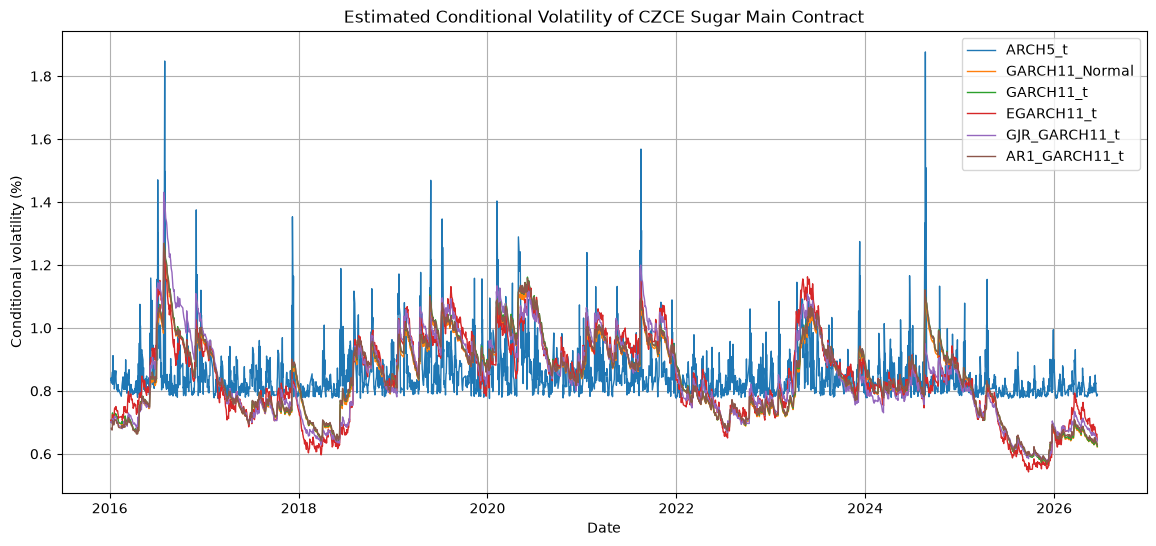

,datetime,ARCH5_t,GARCH11_Normal,GARCH11_t,EGARCH11_t,GJR_GARCH11_t,AR1_GARCH11_t
0,2016-01-05 16:00:00,0.832897,0.700797,0.700980,0.702737,0.701453,NaN
1,2016-01-06 16:00:00,0.841746,0.706876,0.707952,0.707905,0.702759,0.681069
2,2016-01-07 16:00:00,0.824780,0.702331,0.703197,0.699605,0.697982,0.677081
3,2016-01-10 16:00:00,0.851266,0.700638,0.701297,0.706506,0.698451,0.675690
4,2016-01-11 16:00:00,0.860337,0.726780,0.730120,0.724085,0.711404,0.705556


In [28]:
# ============================================================
# Cell 21：画条件波动率
# ============================================================
# 条件波动率 conditional_volatility 是模型估计出来的 sigma_t。
# 它反映模型认为白糖主连在每一天的风险强度。
#
# 注意：
# y 使用的是百分比收益率，因此 conditional_volatility 的单位也是百分比。

vol_df = pd.DataFrame({"datetime": df.loc[y.index, "datetime"].values})

for name, res in models.items():
    vol = pd.Series(res.conditional_volatility, index=y.index)
    vol_df[name] = vol.values

vol_file = OUTPUT_DIR / "08_conditional_volatility.csv"
vol_df.to_csv(vol_file, index=False, encoding="utf-8-sig")

plt.figure(figsize=(14, 6))

for name in models.keys():
    plt.plot(vol_df["datetime"], vol_df[name], label=name, linewidth=1)

plt.title("Estimated Conditional Volatility of CZCE Sugar Main Contract")
plt.xlabel("Date")
plt.ylabel("Conditional volatility (%)")
plt.legend()
plt.grid(True)
plt.show()

vol_df.head()

传统流程下选出的候选最佳模型： EGARCH11_t


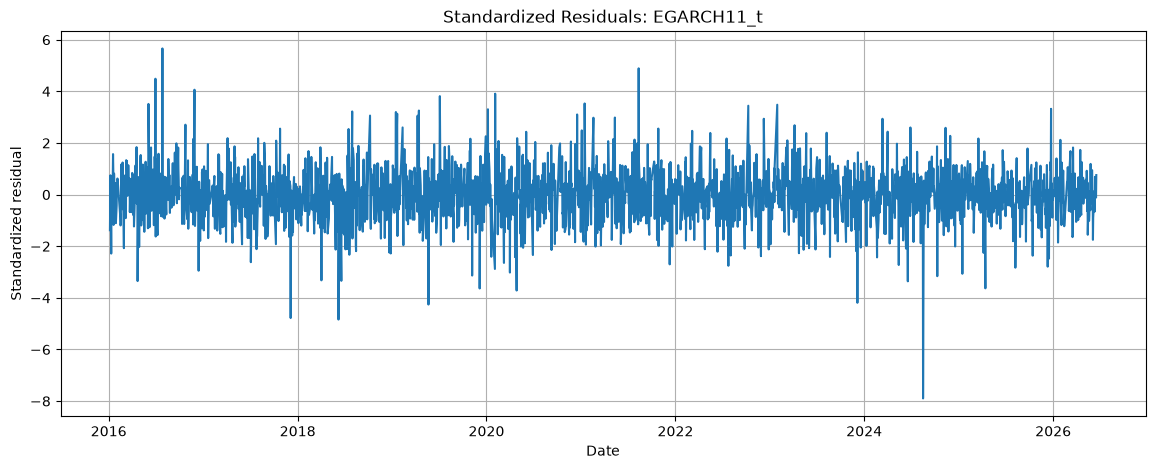

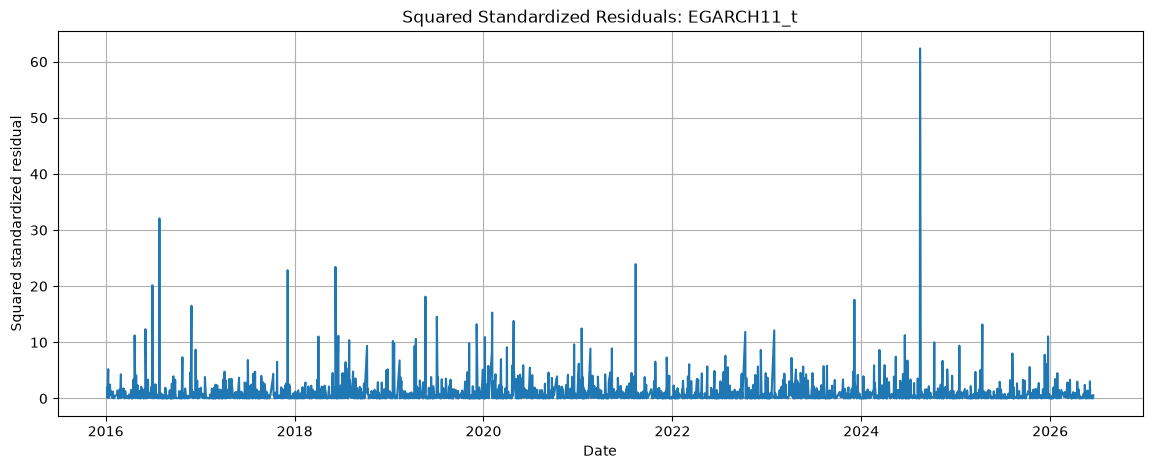

In [29]:
# ============================================================
# Cell 22：画最佳模型的标准化残差
# ============================================================
# 选择逻辑：
# 1. 如果有 PASS 模型，取 AIC 最低的 PASS 模型；
# 2. 如果没有 PASS 模型，取 AIC 最低的模型。
#
# 注意：
# 传统检验通过，不代表模型绝对正确；
# 它只代表在 Ljung-Box / ARCH-LM 这套传统诊断下暂时可接受。

pass_models = core_result[core_result["traditional_decision"] == "PASS"]

if len(pass_models) > 0:
    best_model_name = pass_models.sort_values("aic").iloc[0]["model"]
else:
    best_model_name = core_result.sort_values("aic").iloc[0]["model"]

best_res = models[best_model_name]
best_std_resid = pd.Series(best_res.std_resid, index=y.index).replace([np.inf, -np.inf], np.nan).dropna()

print("传统流程下选出的候选最佳模型：", best_model_name)

plt.figure(figsize=(14, 5))
plt.plot(df.loc[best_std_resid.index, "datetime"], best_std_resid)
plt.title(f"Standardized Residuals: {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Standardized residual")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df.loc[best_std_resid.index, "datetime"], best_std_resid ** 2)
plt.title(f"Squared Standardized Residuals: {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Squared standardized residual")
plt.grid(True)
plt.show()

In [30]:
# ============================================================
# Cell 23：输出最终文字判断
# ============================================================
# 这一格自动根据结果生成传统解释。
# 但最终论文写作时，仍建议你结合参数显著性和图形人工复核。

print("========== 白糖主连传统波动率建模结论 ==========\n")

print("一、数据基础判断")
print(f"ADF(ret_pct) p-value = {adf_ret_p:.6f}")
print(f"Ljung-Box(ret_pct^2, lag10) p-value = {lb_sq_p10:.6f}")
print(f"ARCH-LM(ret_pct, lag10) p-value = {arch_p10:.6f}")

if adf_ret_p < 0.05 and lb_sq_p10 < 0.05 and arch_p10 < 0.05:
    print("结论：收益率平稳，平方收益率存在自相关，ARCH-LM 显著，具备 GARCH 类建模基础。\n")
else:
    print("结论：传统 GARCH 建模基础不完全充分，需要检查数据或样本区间。\n")

print("二、模型比较")
display(core_result)

print("\n三、传统诊断通过情况")
num_pass = (core_result["traditional_decision"] == "PASS").sum()
print(f"通过传统诊断的模型数量：{num_pass}")

if num_pass > 0:
    print(f"传统诊断下候选最佳模型：{best_model_name}")
    print("选择依据：该模型通过标准化残差 Ljung-Box、标准化残差平方 Ljung-Box、ARCH-LM 检验，并在通过模型中 AIC 较低。")
else:
    print(f"没有模型完全通过传统诊断。当前 AIC 最低模型为：{best_model_name}")
    print("含义：传统模型组仍可能遗漏波动率结构，后续应考虑更高阶模型、不同误差分布、样本处理或 Hong-Lee 类更一般检验。")

print("\n四、解释口径")
print("如果 LB_z_lag10_pvalue < 0.05：说明标准化残差本身仍有方向性自相关，均值方程可能不充分。")
print("如果 LB_z2_lag10_pvalue < 0.05：说明标准化残差平方仍有自相关，方差方程没有完全解释波动率聚集。")
print("如果 ARCH_LM_lag10_pvalue < 0.05：说明标准化残差仍有剩余 ARCH 效应。")
print("如果 Student-t 模型 AIC/BIC 明显优于 Normal：说明厚尾分布更适合白糖收益率。")
print("如果 GJR / EGARCH 的 gamma 显著且诊断改善：说明正负冲击对白糖未来波动率影响可能不对称。")

========== 白糖主连传统波动率建模结论 ==========

一、数据基础判断
ADF(ret_pct) p-value = 0.000000
Ljung-Box(ret_pct^2, lag10) p-value = 0.470906
ARCH-LM(ret_pct, lag10) p-value = 0.505579
结论：传统 GARCH 建模基础不完全充分，需要检查数据或样本区间。

二、模型比较


,model,aic,bic,alpha[1],gamma[1],beta[1],nu,alpha_plus_beta,gjr_persistence_approx,LB_z_lag10_pvalue,LB_z2_lag10_pvalue,ARCH_LM_lag10_pvalue,traditional_decision
0,EGARCH11_t,"5,969.511547","6,004.541607",0.057641,0.019412,0.989908,4.497111,1.047549,1.057255,0.321999,0.862060,0.869068,PASS
1,AR1_GARCH11_t,"5,974.928655","6,009.956349",0.018904,NaN,0.976105,4.456365,0.995009,NaN,0.348248,0.804956,0.805507,PASS
2,GJR_GARCH11_t,"5,975.336108","6,010.366168",0.028719,-0.018915,0.973763,4.476455,1.002482,0.993024,0.329608,0.855821,0.863008,PASS
3,GARCH11_t,"5,978.885458","6,008.077174",0.018924,NaN,0.976385,4.483401,0.995309,NaN,0.327992,0.814196,0.819051,PASS
4,ARCH5_t,"6,025.658460","6,072.365207",0.032462,NaN,NaN,4.269752,NaN,NaN,0.160875,0.993404,0.993778,PASS
5,GARCH11_Normal,"6,236.612105","6,259.965478",0.017454,NaN,0.977507,NaN,0.994961,NaN,0.321872,0.836357,0.841753,PASS



三、传统诊断通过情况
通过传统诊断的模型数量：6
传统诊断下候选最佳模型：EGARCH11_t
选择依据：该模型通过标准化残差 Ljung-Box、标准化残差平方 Ljung-Box、ARCH-LM 检验，并在通过模型中 AIC 较低。

四、解释口径
如果 LB_z_lag10_pvalue < 0.05：说明标准化残差本身仍有方向性自相关，均值方程可能不充分。
如果 LB_z2_lag10_pvalue < 0.05：说明标准化残差平方仍有自相关，方差方程没有完全解释波动率聚集。
如果 ARCH_LM_lag10_pvalue < 0.05：说明标准化残差仍有剩余 ARCH 效应。
如果 Student-t 模型 AIC/BIC 明显优于 Normal：说明厚尾分布更适合白糖收益率。
如果 GJR / EGARCH 的 gamma 显著且诊断改善：说明正负冲击对白糖未来波动率影响可能不对称。


In [31]:
# ============================================================
# Cell 25：后续扩展接口
# ============================================================
# 后面如果你要接 Hong-Lee 检验，最重要的输入就是：
# 1. best_model_name
# 2. best_std_resid
#
# Hong-Lee 的思想是：
# 传统 Ljung-Box 只看 z_t^2 的线性自相关；
# Hong-Lee 要进一步检查标准化残差是否还存在更一般的线性 / 非线性条件方差依赖。

hong_lee_input = pd.DataFrame({
    "datetime": df.loc[best_std_resid.index, "datetime"].values,
    "std_resid": best_std_resid.values,
    "std_resid_sq": best_std_resid.values ** 2
})

hong_lee_input_file = OUTPUT_DIR / "09_hong_lee_input_standardized_residuals.csv"
hong_lee_input.to_csv(hong_lee_input_file, index=False, encoding="utf-8-sig")

print("Hong-Lee 后续检验输入文件已保存：", hong_lee_input_file.resolve())

hong_lee_input.head()

Hong-Lee 后续检验输入文件已保存： /home/zilinm2/sr_traditional_volatility_output/09_hong_lee_input_standardized_residuals.csv


,datetime,std_resid,std_resid_sq
0,2016-01-05 16:00:00,-1.379095,1.901904
1,2016-01-06 16:00:00,-0.382654,0.146424
2,2016-01-07 16:00:00,0.747621,0.558937
3,2016-01-10 16:00:00,-2.284431,5.218626
4,2016-01-11 16:00:00,-0.480546,0.230924


In [32]:
# ============================================================
# Cell 26：确认 EGARCH11_t 是否存在，并设为目标模型
# ============================================================
# 这一步不重新估计模型，直接复用前面 Cell 15 中已经拟合好的 models。
# 如果 EGARCH11_t 存在，则指定它为目标模型。
# 如果不存在，则报错提醒你先回到前面重新拟合。

TARGET_MODEL_NAME = "EGARCH11_t"

required_vars = ["df", "y", "models", "OUTPUT_DIR"]

for var in required_vars:
    if var not in globals():
        raise NameError(f"{var} 不存在。请先运行前面传统建模流程对应 Cell。")

if TARGET_MODEL_NAME not in models:
    raise ValueError(
        f"{TARGET_MODEL_NAME} 不在 models 中。当前可用模型为：{list(models.keys())}"
    )

egarch_res = models[TARGET_MODEL_NAME]

print("目标模型：", TARGET_MODEL_NAME)
print("样本量：", egarch_res.nobs)
print("AIC：", egarch_res.aic)
print("BIC：", egarch_res.bic)

egarch_res.summary()

目标模型： EGARCH11_t
样本量： 2536
AIC： 5969.511546903005
BIC： 6004.541606796348


<class 'statsmodels.iolib.summary.Summary'>
"""
                        Constant Mean - EGARCH Model Results                        
====================================================================================
Dep. Variable:                      ret_pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -2978.76
Distribution:      Standardized Student's t   AIC:                           5969.51
Method:                  Maximum Likelihood   BIC:                           6004.54
                                              No. Observations:                 2536
Date:                      Wed, Jun 17 2026   Df Residuals:                     2535
Time:                              03:14:53   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         2.2590e-06  9.874e-04  2.288e-03      0.998 [-1.933e-03,1.938e-03]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      8.0368e-04  2.357e-03      0.341      0.733 [-3.815e-03,5.423e-03]
alpha[1]       0.0576  1.325e-02      4.349  1.369e-05  [3.166e-02,8.362e-02]
gamma[1]       0.0194  1.048e-02      1.853  6.389e-02 [-1.121e-03,3.995e-02]
beta[1]        0.9899  4.846e-03    204.290      0.000      [  0.980,  0.999]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             4.4971      0.405     11.114  1.068e-28 [  3.704,  5.290]
========================================================================

Covariance estimator: robust
"""

In [33]:
# ============================================================
# Cell 27：提取 EGARCH11_t 参数并做基础解释
# ============================================================
# EGARCH(1,1)-t 重点看：
#
# mu        ：收益率均值项
# omega     ：长期对数方差基础项
# alpha[1]  ：冲击幅度项，反映冲击大小对波动率的影响
# gamma[1]  ：非对称项，反映正负冲击对未来波动率影响是否不同
# beta[1]   ：波动率持续性
# nu        ：Student-t 自由度，越低说明厚尾越强

params = egarch_res.params
pvalues = egarch_res.pvalues

egarch_param_table = pd.DataFrame({
    "parameter": params.index,
    "estimate": params.values,
    "p_value": [pvalues.get(k, np.nan) for k in params.index]
})

egarch_param_table["significant_5pct"] = egarch_param_table["p_value"] < 0.05

param_file = OUTPUT_DIR / "10_egarch11_t_parameters.csv"
egarch_param_table.to_csv(param_file, index=False, encoding="utf-8-sig")

egarch_param_table

,parameter,estimate,p_value,significant_5pct
0,mu,0.000002,0.998175,False
1,omega,0.000804,0.733086,False
2,alpha[1],0.057641,0.000014,True
3,gamma[1],0.019412,0.063891,False
4,beta[1],0.989908,0.000000,True
5,nu,4.497111,0.000000,True


In [34]:
# ============================================================
# Cell 28：自动生成 EGARCH 参数解释
# ============================================================

def safe_get_param(name):
    return float(params.get(name, np.nan))

def safe_get_pvalue(name):
    return float(pvalues.get(name, np.nan))

mu = safe_get_param("mu")
omega = safe_get_param("omega")
alpha1 = safe_get_param("alpha[1]")
gamma1 = safe_get_param("gamma[1]")
beta1 = safe_get_param("beta[1]")
nu = safe_get_param("nu")

gamma_p = safe_get_pvalue("gamma[1]")
alpha_p = safe_get_pvalue("alpha[1]")
beta_p = safe_get_pvalue("beta[1]")
nu_p = safe_get_pvalue("nu")

print("========== EGARCH(1,1)-t 参数解释 ==========\n")

print(f"mu        = {mu:.6f}")
print(f"omega     = {omega:.6f}")
print(f"alpha[1]  = {alpha1:.6f}, p-value = {alpha_p:.6f}")
print(f"gamma[1]  = {gamma1:.6f}, p-value = {gamma_p:.6f}")
print(f"beta[1]   = {beta1:.6f}, p-value = {beta_p:.6f}")
print(f"nu        = {nu:.6f}, p-value = {nu_p:.6f}")

print("\n---------- 解释 ----------")

if not np.isnan(alpha1):
    if alpha_p < 0.05:
        print("1. alpha[1] 显著：冲击幅度会显著影响白糖未来波动率。")
    else:
        print("1. alpha[1] 不显著：冲击幅度对未来波动率的影响在统计上不强。")

if not np.isnan(beta1):
    if beta_p < 0.05:
        print("2. beta[1] 显著：白糖波动率具有显著持续性。")
    else:
        print("2. beta[1] 不显著：波动率持续性证据不强。")
    
    if abs(beta1) > 0.90:
        print("   beta[1] 接近 1：高波动状态可能持续较久。")
    elif abs(beta1) > 0.70:
        print("   beta[1] 较高：波动率有一定持续性。")
    else:
        print("   beta[1] 不高：波动率冲击衰减可能较快。")

if not np.isnan(gamma1):
    if gamma_p < 0.05:
        print("3. gamma[1] 显著：正负冲击对白糖未来波动率的影响存在非对称性。")
        if gamma1 < 0:
            print("   在 arch 包 EGARCH 设定下，gamma[1] < 0 通常表示负冲击更容易推高未来波动率。")
        elif gamma1 > 0:
            print("   在 arch 包 EGARCH 设定下，gamma[1] > 0 通常表示正冲击更容易推高未来波动率。")
    else:
        print("3. gamma[1] 不显著：非对称波动证据不强。")

if not np.isnan(nu):
    print("4. nu 是 Student-t 自由度。")
    if nu < 5:
        print("   nu 较低：白糖收益率厚尾非常明显，极端波动风险较高。")
    elif nu < 10:
        print("   nu 偏低：白糖收益率存在明显厚尾。")
    else:
        print("   nu 较高：厚尾存在但相对温和。")

========== EGARCH(1,1)-t 参数解释 ==========

mu        = 0.000002
omega     = 0.000804
alpha[1]  = 0.057641, p-value = 0.000014
gamma[1]  = 0.019412, p-value = 0.063891
beta[1]   = 0.989908, p-value = 0.000000
nu        = 4.497111, p-value = 0.000000

---------- 解释 ----------
1. alpha[1] 显著：冲击幅度会显著影响白糖未来波动率。
2. beta[1] 显著：白糖波动率具有显著持续性。
   beta[1] 接近 1：高波动状态可能持续较久。
3. gamma[1] 不显著：非对称波动证据不强。
4. nu 是 Student-t 自由度。
   nu 较低：白糖收益率厚尾非常明显，极端波动风险较高。


In [35]:
# ============================================================
# Cell 29：重新确认 EGARCH11_t 的标准化残差诊断
# ============================================================
# 传统模型选出后，必须再次确认：
# 1. 标准化残差 z_t 是否还有自相关；
# 2. 标准化残差平方 z_t^2 是否还有自相关；
# 3. 是否仍有剩余 ARCH 效应。
#
# 如果三者都不显著，说明 EGARCH11_t 在传统诊断下基本可用。

std_resid = pd.Series(egarch_res.std_resid, index=y.index)
std_resid = std_resid.replace([np.inf, -np.inf], np.nan).dropna()
std_resid_sq = std_resid ** 2

lb_z = acorr_ljungbox(std_resid, lags=[5, 10, 20, 30], return_df=True)
lb_z2 = acorr_ljungbox(std_resid_sq, lags=[5, 10, 20, 30], return_df=True)

arch_lm_std = het_arch(std_resid, nlags=10)

egarch_diag = pd.DataFrame({
    "test": [
        "LB_z_lag5",
        "LB_z_lag10",
        "LB_z_lag20",
        "LB_z_lag30",
        "LB_z2_lag5",
        "LB_z2_lag10",
        "LB_z2_lag20",
        "LB_z2_lag30",
        "ARCH_LM_lag10"
    ],
    "p_value": [
        lb_z.loc[5, "lb_pvalue"],
        lb_z.loc[10, "lb_pvalue"],
        lb_z.loc[20, "lb_pvalue"],
        lb_z.loc[30, "lb_pvalue"],
        lb_z2.loc[5, "lb_pvalue"],
        lb_z2.loc[10, "lb_pvalue"],
        lb_z2.loc[20, "lb_pvalue"],
        lb_z2.loc[30, "lb_pvalue"],
        arch_lm_std[1]
    ]
})

egarch_diag["pass_5pct"] = egarch_diag["p_value"] > 0.05

diag_file = OUTPUT_DIR / "11_egarch11_t_residual_diagnostics.csv"
egarch_diag.to_csv(diag_file, index=False, encoding="utf-8-sig")

egarch_diag

,test,p_value,pass_5pct
0,LB_z_lag5,0.140810,True
1,LB_z_lag10,0.321999,True
2,LB_z_lag20,0.538420,True
3,LB_z_lag30,0.796358,True
4,LB_z2_lag5,0.770292,True
5,LB_z2_lag10,0.862060,True
6,LB_z2_lag20,0.815224,True
7,LB_z2_lag30,0.954347,True
8,ARCH_LM_lag10,0.869068,True


In [36]:
# ============================================================
# Cell 30：构造 EGARCH 条件波动率序列
# ============================================================
# conditional_volatility 是模型估计出来的 sigma_t。
# 因为 y = ret_pct，所以这里的 volatility 单位也是“百分比收益率”。
#
# 例如：
# conditional_volatility = 1.2
# 表示模型认为该日白糖收益率的一倍标准差波动约为 1.2%。

egarch_vol = pd.Series(egarch_res.conditional_volatility, index=y.index)
egarch_vol = egarch_vol.replace([np.inf, -np.inf], np.nan).dropna()

egarch_usage = pd.DataFrame({
    "datetime": df.loc[egarch_vol.index, "datetime"].values,
    "close": df.loc[egarch_vol.index, "close"].values,
    "ret_pct": df.loc[egarch_vol.index, "ret_pct"].values,
    "egarch_vol_pct": egarch_vol.values,
    "std_resid": std_resid.reindex(egarch_vol.index).values
})

egarch_usage["egarch_vol_pctile"] = egarch_usage["egarch_vol_pct"].rank(pct=True)

egarch_usage.head()

,datetime,close,ret_pct,egarch_vol_pct,std_resid,egarch_vol_pctile
0,2016-01-05 16:00:00,"5,545.000000",-0.969139,0.702737,-1.379095,0.142744
1,2016-01-06 16:00:00,"5,530.000000",-0.270881,0.707905,-0.382654,0.152208
2,2016-01-07 16:00:00,"5,559.000000",0.523042,0.699605,0.747621,0.140379
3,2016-01-10 16:00:00,"5,470.000000",-1.613962,0.706506,-2.284431,0.148659
4,2016-01-11 16:00:00,"5,451.000000",-0.347954,0.724085,-0.480546,0.181388


In [37]:
# ============================================================
# Cell 31：按历史分位划分波动率状态
# ============================================================
# 这里把 EGARCH 条件波动率转换成状态变量。
#
# 分位解释：
# 0% - 20%   ：低波动
# 20% - 80%  ：常态波动
# 80% - 95%  ：高波动
# 95% - 100% ：极端高波动
#
# 这个状态可用于仓位管理、止损宽度、风险预警。

def classify_vol_state(p):
    if p < 0.20:
        return "low_vol"
    elif p < 0.80:
        return "normal_vol"
    elif p < 0.95:
        return "high_vol"
    else:
        return "extreme_high_vol"

egarch_usage["vol_state"] = egarch_usage["egarch_vol_pctile"].apply(classify_vol_state)

vol_state_summary = (
    egarch_usage
    .groupby("vol_state")
    .agg(
        count=("vol_state", "count"),
        avg_vol_pct=("egarch_vol_pct", "mean"),
        median_vol_pct=("egarch_vol_pct", "median"),
        avg_abs_ret_pct=("ret_pct", lambda x: x.abs().mean()),
        max_abs_ret_pct=("ret_pct", lambda x: x.abs().max())
    )
    .reset_index()
)

usage_file = OUTPUT_DIR / "12_egarch11_t_volatility_usage_table.csv"
summary_file = OUTPUT_DIR / "13_egarch11_t_vol_state_summary.csv"

egarch_usage.to_csv(usage_file, index=False, encoding="utf-8-sig")
vol_state_summary.to_csv(summary_file, index=False, encoding="utf-8-sig")

vol_state_summary

,vol_state,count,avg_vol_pct,median_vol_pct,avg_abs_ret_pct,max_abs_ret_pct
0,extreme_high_vol,127,1.106464,1.103650,0.706595,2.586106
1,high_vol,381,1.007832,1.006591,0.719464,5.803307
2,low_vol,507,0.657230,0.662188,0.468969,3.040204
3,normal_vol,1521,0.840411,0.832278,0.615452,5.891147


In [38]:
# ============================================================
# Cell 32：查看最近交易日的波动率状态
# ============================================================

latest_row = egarch_usage.iloc[-1]

print("========== 最新 EGARCH 波动率状态 ==========")
print("日期：", latest_row["datetime"])
print("收盘价：", latest_row["close"])
print("当日收益率 %：", round(latest_row["ret_pct"], 4))
print("EGARCH 条件波动率 %：", round(latest_row["egarch_vol_pct"], 4))
print("历史波动率分位：", round(latest_row["egarch_vol_pctile"] * 100, 2), "%")
print("波动率状态：", latest_row["vol_state"])

if latest_row["vol_state"] == "low_vol":
    print("解释：当前处于低波动压缩区，风险表面较低，但后续可能出现波动率扩张。")
elif latest_row["vol_state"] == "normal_vol":
    print("解释：当前处于历史常态波动区，风险水平正常。")
elif latest_row["vol_state"] == "high_vol":
    print("解释：当前处于高波动区，仓位和止损需要更谨慎。")
else:
    print("解释：当前处于极端高波动区，应优先控制仓位和保证金风险。")

========== 最新 EGARCH 波动率状态 ==========
日期： 2026-06-16 16:00:00
收盘价： 5343.0
当日收益率 %： 0.4878
EGARCH 条件波动率 %： 0.6445
历史波动率分位： 8.24 %
波动率状态： low_vol
解释：当前处于低波动压缩区，风险表面较低，但后续可能出现波动率扩张。


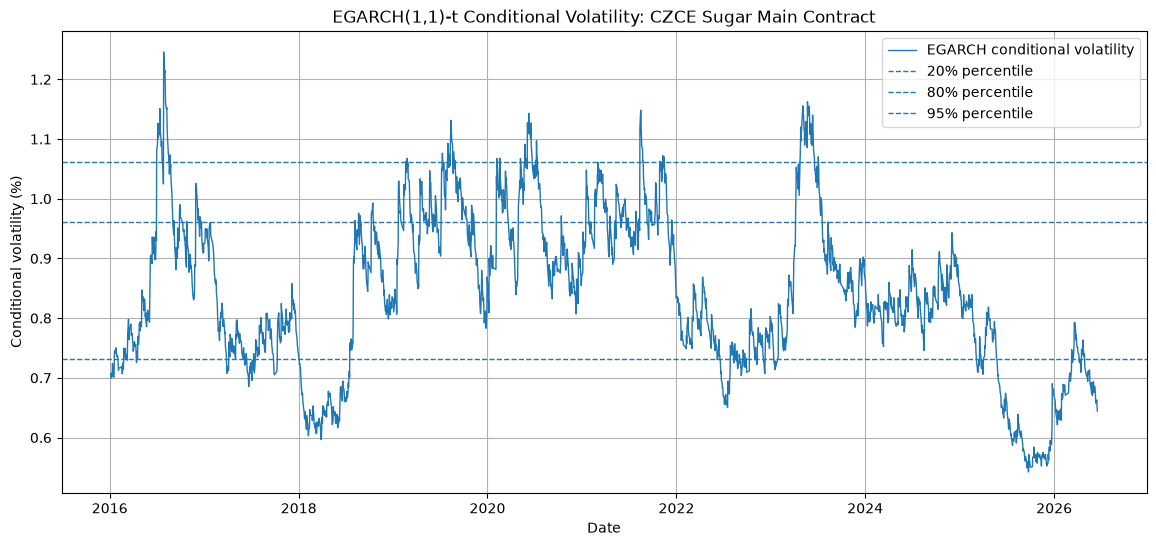

In [39]:
# ============================================================
# Cell 33：画 EGARCH 条件波动率与分位阈值
# ============================================================

vol_q20 = egarch_usage["egarch_vol_pct"].quantile(0.20)
vol_q80 = egarch_usage["egarch_vol_pct"].quantile(0.80)
vol_q95 = egarch_usage["egarch_vol_pct"].quantile(0.95)

plt.figure(figsize=(14, 6))
plt.plot(
    egarch_usage["datetime"],
    egarch_usage["egarch_vol_pct"],
    label="EGARCH conditional volatility",
    linewidth=1
)

plt.axhline(vol_q20, linestyle="--", linewidth=1, label="20% percentile")
plt.axhline(vol_q80, linestyle="--", linewidth=1, label="80% percentile")
plt.axhline(vol_q95, linestyle="--", linewidth=1, label="95% percentile")

plt.title("EGARCH(1,1)-t Conditional Volatility: CZCE Sugar Main Contract")
plt.xlabel("Date")
plt.ylabel("Conditional volatility (%)")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
# ============================================================
# Cell 34：提取历史高波动日期
# ============================================================
# 这一步用于后续人工复盘：
# 哪些日期 EGARCH 认为白糖波动率极高？
# 是否对应换月、政策、天气、库存、宏观风险、资金冲击？

top_high_vol_days = (
    egarch_usage
    .sort_values("egarch_vol_pct", ascending=False)
    .head(30)
    .reset_index(drop=True)
)

top_high_vol_file = OUTPUT_DIR / "14_egarch11_t_top_high_vol_days.csv"
top_high_vol_days.to_csv(top_high_vol_file, index=False, encoding="utf-8-sig")

top_high_vol_days[
    ["datetime", "close", "ret_pct", "egarch_vol_pct", "egarch_vol_pctile", "vol_state"]
]

,datetime,close,ret_pct,egarch_vol_pct,egarch_vol_pctile,vol_state
0,2016-07-27 16:00:00,"6,124.000000",-1.071961,1.245857,1.000000,extreme_high_vol
1,2016-07-28 16:00:00,"6,105.000000",-0.310737,1.235478,0.999606,extreme_high_vol
2,2016-08-01 16:00:00,"6,134.000000",-0.374258,1.214087,0.999211,extreme_high_vol
3,2016-07-31 16:00:00,"6,157.000000",0.848154,1.211111,0.998817,extreme_high_vol
4,2016-08-02 16:00:00,"6,136.000000",0.032600,1.191643,0.998423,extreme_high_vol
5,2016-08-03 16:00:00,"6,070.000000",-1.081446,1.164188,0.998028,extreme_high_vol
6,2023-05-22 16:00:00,"7,166.000000",0.517665,1.162388,0.997634,extreme_high_vol
7,2016-08-04 16:00:00,"6,103.000000",0.542185,1.156793,0.997240,extreme_high_vol
8,2023-05-04 16:00:00,"6,925.000000",0.260266,1.155661,0.996845,extreme_high_vol
9,2023-05-29 16:00:00,"6,870.000000",-0.696260,1.154931,0.996451,extreme_high_vol


In [41]:
# ============================================================
# Cell 35：EGARCH 未来 1 / 5 / 10 日波动率预测
# ============================================================
# 对 EGARCH 这类非线性模型，多步预测建议使用 simulation 方法。
#
# 这里 forecast horizon=10。
# 输出 h.1 到 h.10 的条件方差预测，并转成波动率。
#
# 注意：
# 单位仍然是百分比收益率。
# h.1 表示下一交易日；
# h.5 表示未来第 5 个交易日；
# h.10 表示未来第 10 个交易日。

forecast_horizon = 10

egarch_forecast = egarch_res.forecast(
    horizon=forecast_horizon,
    method="simulation",
    simulations=5000,
    reindex=False
)

variance_forecast = egarch_forecast.variance.iloc[-1]
vol_forecast = np.sqrt(variance_forecast)

forecast_table = pd.DataFrame({
    "horizon": np.arange(1, forecast_horizon + 1),
    "variance_forecast": variance_forecast.values,
    "vol_forecast_pct": vol_forecast.values
})

forecast_table["vol_forecast_pctile_vs_history"] = forecast_table["vol_forecast_pct"].apply(
    lambda x: (egarch_usage["egarch_vol_pct"] <= x).mean()
)

forecast_file = OUTPUT_DIR / "15_egarch11_t_volatility_forecast.csv"
forecast_table.to_csv(forecast_file, index=False, encoding="utf-8-sig")

forecast_table

,horizon,variance_forecast,vol_forecast_pct,vol_forecast_pctile_vs_history
0,1,0.424597,0.651611,0.087934
1,2,0.427242,0.653638,0.091088
2,3,0.429675,0.655496,0.093454
3,4,0.432876,0.657933,0.094637
4,5,0.435321,0.659789,0.095820
5,6,0.437704,0.661592,0.098975
6,7,0.440291,0.663544,0.101341
7,8,0.443475,0.665939,0.104101
8,9,0.445989,0.667824,0.106073
9,10,0.448712,0.669860,0.108044


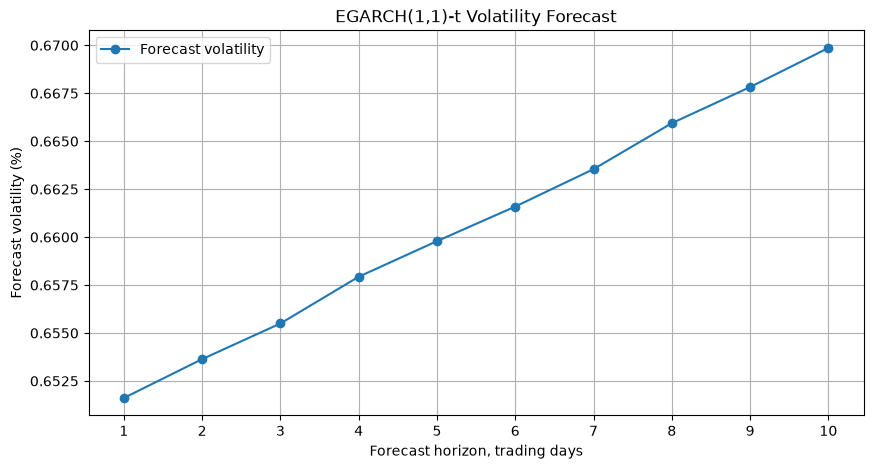

In [42]:
# ============================================================
# Cell 36：画未来 10 日预测波动率
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(
    forecast_table["horizon"],
    forecast_table["vol_forecast_pct"],
    marker="o",
    label="Forecast volatility"
)

plt.title("EGARCH(1,1)-t Volatility Forecast")
plt.xlabel("Forecast horizon, trading days")
plt.ylabel("Forecast volatility (%)")
plt.xticks(forecast_table["horizon"])
plt.grid(True)
plt.legend()
plt.show()

In [43]:
# ============================================================
# Cell 37：构造下一交易日 95% / 99% VaR
# ============================================================
# VaR 用途：
# 在当前 EGARCH 波动率和 Student-t 厚尾分布假设下，
# 估计下一交易日可能出现的极端亏损边界。
#
# 注意：
# 这里 y 使用 ret_pct，所以 VaR 单位也是 %。
#
# 对多头：
# 下尾风险是收益率过低，因此看 1% / 5% 左尾分位。
#
# 对空头：
# 上尾风险是收益率过高，因此看 95% / 99% 右尾分位。

from scipy.stats import t as student_t

# EGARCH-t 的 nu
nu = float(egarch_res.params.get("nu", np.nan))

if np.isnan(nu):
    raise ValueError("当前模型没有 Student-t 自由度参数 nu，不能按 t 分布计算 VaR。")

# arch 包中的 t 分布是标准化 t。
# 普通 t 分布方差为 nu / (nu - 2)，为了让方差为 1，需要乘 sqrt((nu - 2) / nu)。
std_t_scale = np.sqrt((nu - 2) / nu)

q_01 = student_t.ppf(0.01, df=nu) * std_t_scale
q_05 = student_t.ppf(0.05, df=nu) * std_t_scale
q_95 = student_t.ppf(0.95, df=nu) * std_t_scale
q_99 = student_t.ppf(0.99, df=nu) * std_t_scale

# 下一交易日预测波动率
next_vol = forecast_table.loc[forecast_table["horizon"] == 1, "vol_forecast_pct"].iloc[0]

# 均值项。EGARCH11_t 当前是 Constant Mean，所以用 mu。
next_mu = float(egarch_res.params.get("mu", 0.0))

next_var_table = pd.DataFrame({
    "risk_measure": [
        "Long position 95% VaR lower return",
        "Long position 99% VaR lower return",
        "Short position 95% VaR upper return",
        "Short position 99% VaR upper return"
    ],
    "return_threshold_pct": [
        next_mu + next_vol * q_05,
        next_mu + next_vol * q_01,
        next_mu + next_vol * q_95,
        next_mu + next_vol * q_99
    ]
})

var_next_file = OUTPUT_DIR / "16_egarch11_t_next_day_var.csv"
next_var_table.to_csv(var_next_file, index=False, encoding="utf-8-sig")

print("下一交易日预测均值 %：", round(next_mu, 6))
print("下一交易日预测波动率 %：", round(next_vol, 6))
print("Student-t nu：", round(nu, 6))

next_var_table

下一交易日预测均值 %： 2e-06
下一交易日预测波动率 %： 0.651611
Student-t nu： 4.497111


,risk_measure,return_threshold_pct
0,Long position 95% VaR lower return,-1.003114
1,Long position 99% VaR lower return,-1.713107
2,Short position 95% VaR upper return,1.003118
3,Short position 99% VaR upper return,1.713111


In [44]:
# ============================================================
# Cell 38：把 VaR 转成价格区间参考
# ============================================================
# 这里把收益率 VaR 转成下一交易日价格阈值。
#
# 注意：
# 这是统计风险区间，不是价格预测。
# 它表示在 EGARCH-t 假设下，下一交易日价格跌破 / 涨破某阈值的概率边界。

last_close = egarch_usage["close"].iloc[-1]

price_var_table = next_var_table.copy()
price_var_table["last_close"] = last_close

# return_threshold_pct 是百分比收益率，需要除以 100 再指数还原价格。
price_var_table["price_threshold"] = last_close * np.exp(
    price_var_table["return_threshold_pct"] / 100
)

price_var_file = OUTPUT_DIR / "17_egarch11_t_next_day_var_price_threshold.csv"
price_var_table.to_csv(price_var_file, index=False, encoding="utf-8-sig")

price_var_table

,risk_measure,return_threshold_pct,last_close,price_threshold
0,Long position 95% VaR lower return,-1.003114,"5,343.000000","5,289.671542"
1,Long position 99% VaR lower return,-1.713107,"5,343.000000","5,252.248253"
2,Short position 95% VaR upper return,1.003118,"5,343.000000","5,396.866339"
3,Short position 99% VaR upper return,1.713111,"5,343.000000","5,435.320060"


In [45]:
# ============================================================
# Cell 39：构造样本内一日 VaR 序列
# ============================================================
# 这一步用历史拟合出来的条件波动率构造一日 VaR 序列。
#
# 注意：
# 严格样本外 VaR 需要滚动重新估计模型。
# 这里先做传统研究中常见的样本内 fitted VaR 检查，
# 用于初步观察 EGARCH-t 的风险刻画是否合理。

var_usage = egarch_usage.copy()

var_usage["mu_pct"] = next_mu
var_usage["VaR_95_long_return_pct"] = var_usage["mu_pct"] + var_usage["egarch_vol_pct"] * q_05
var_usage["VaR_99_long_return_pct"] = var_usage["mu_pct"] + var_usage["egarch_vol_pct"] * q_01

var_usage["VaR_95_short_return_pct"] = var_usage["mu_pct"] + var_usage["egarch_vol_pct"] * q_95
var_usage["VaR_99_short_return_pct"] = var_usage["mu_pct"] + var_usage["egarch_vol_pct"] * q_99

# 多头 VaR 突破：实际收益率低于左尾阈值
var_usage["exception_95_long"] = var_usage["ret_pct"] < var_usage["VaR_95_long_return_pct"]
var_usage["exception_99_long"] = var_usage["ret_pct"] < var_usage["VaR_99_long_return_pct"]

# 空头 VaR 突破：实际收益率高于右尾阈值
var_usage["exception_95_short"] = var_usage["ret_pct"] > var_usage["VaR_95_short_return_pct"]
var_usage["exception_99_short"] = var_usage["ret_pct"] > var_usage["VaR_99_short_return_pct"]

var_usage_file = OUTPUT_DIR / "18_egarch11_t_fitted_var_series.csv"
var_usage.to_csv(var_usage_file, index=False, encoding="utf-8-sig")

var_usage.tail()

,datetime,close,ret_pct,egarch_vol_pct,std_resid,egarch_vol_pctile,vol_state,mu_pct,VaR_95_long_return_pct,VaR_99_long_return_pct,VaR_95_short_return_pct,VaR_99_short_return_pct,exception_95_long,exception_99_long,exception_95_short,exception_99_short
2531,2026-06-10 16:00:00,"5,291.000000",-0.433758,0.661281,-0.655940,0.098975,low_vol,0.000002,-1.018001,-1.738531,1.018005,1.738535,False,False,False,False
2532,2026-06-11 16:00:00,"5,315.000000",0.452575,0.657403,0.688425,0.094637,low_vol,0.000002,-1.012031,-1.728335,1.012035,1.728339,False,False,False,False
2533,2026-06-14 16:00:00,"5,321.000000",0.112824,0.662791,0.170223,0.100552,low_vol,0.000002,-1.020325,-1.742500,1.020330,1.742504,False,False,False,False
2534,2026-06-15 16:00:00,"5,317.000000",-0.075202,0.654960,-0.114823,0.093060,low_vol,0.000002,-1.008271,-1.721913,1.008275,1.721918,False,False,False,False
2535,2026-06-16 16:00:00,"5,343.000000",0.487806,0.644482,0.756893,0.082413,low_vol,0.000002,-0.992140,-1.694365,0.992144,1.694370,False,False,False,False


In [46]:
# ============================================================
# Cell 40：VaR 突破率统计
# ============================================================
# 理论上：
# 95% VaR 的突破率应该接近 5%
# 99% VaR 的突破率应该接近 1%
#
# 如果突破率明显高于理论值，说明模型低估尾部风险。
# 如果突破率明显低于理论值，说明模型过于保守。

def exception_summary(series, expected_rate):
    n = len(series)
    exceptions = int(series.sum())
    rate = exceptions / n
    return {
        "n_obs": n,
        "exceptions": exceptions,
        "exception_rate": rate,
        "expected_rate": expected_rate,
        "difference": rate - expected_rate
    }

var_exception_summary = pd.DataFrame([
    {
        "side": "long",
        "confidence": "95%",
        **exception_summary(var_usage["exception_95_long"], 0.05)
    },
    {
        "side": "long",
        "confidence": "99%",
        **exception_summary(var_usage["exception_99_long"], 0.01)
    },
    {
        "side": "short",
        "confidence": "95%",
        **exception_summary(var_usage["exception_95_short"], 0.05)
    },
    {
        "side": "short",
        "confidence": "99%",
        **exception_summary(var_usage["exception_99_short"], 0.01)
    }
])

exception_file = OUTPUT_DIR / "19_egarch11_t_var_exception_summary.csv"
var_exception_summary.to_csv(exception_file, index=False, encoding="utf-8-sig")

var_exception_summary

,side,confidence,n_obs,exceptions,exception_rate,expected_rate,difference
0,long,95%,2536,136,0.053628,0.050000,0.003628
1,long,99%,2536,24,0.009464,0.010000,-0.000536
2,short,95%,2536,120,0.047319,0.050000,-0.002681
3,short,99%,2536,25,0.009858,0.010000,-0.000142


In [47]:
# ============================================================
# Cell 41：Kupiec VaR 覆盖率检验
# ============================================================
# Kupiec POF test：
# 检验 VaR 的实际突破率是否等于理论突破率。
#
# H0：实际突破率 = 理论突破率
# H1：实际突破率 != 理论突破率
#
# p-value > 0.05：
#     不能拒绝 H0，VaR 覆盖率基本合理。
#
# p-value < 0.05：
#     拒绝 H0，VaR 覆盖率不合理。

from scipy.stats import chi2

def kupiec_pof_test(exception_series, expected_prob):
    exception_series = pd.Series(exception_series).astype(bool)
    n = len(exception_series)
    x = int(exception_series.sum())
    
    if x == 0:
        # 没有突破时，似然中 x/n 为 0，单独处理
        pi_hat = 0.0
    else:
        pi_hat = x / n
    
    p = expected_prob
    
    # 避免 log(0)
    eps = 1e-12
    pi_hat_clip = min(max(pi_hat, eps), 1 - eps)
    p_clip = min(max(p, eps), 1 - eps)
    
    log_likelihood_null = (n - x) * np.log(1 - p_clip) + x * np.log(p_clip)
    log_likelihood_alt = (n - x) * np.log(1 - pi_hat_clip) + x * np.log(pi_hat_clip)
    
    lr_stat = -2 * (log_likelihood_null - log_likelihood_alt)
    p_value = 1 - chi2.cdf(lr_stat, df=1)
    
    return {
        "n_obs": n,
        "exceptions": x,
        "expected_prob": p,
        "actual_prob": pi_hat,
        "kupiec_lr_stat": lr_stat,
        "kupiec_p_value": p_value,
        "decision_5pct": "pass" if p_value > 0.05 else "reject"
    }

kupiec_results = pd.DataFrame([
    {
        "side": "long",
        "confidence": "95%",
        **kupiec_pof_test(var_usage["exception_95_long"], 0.05)
    },
    {
        "side": "long",
        "confidence": "99%",
        **kupiec_pof_test(var_usage["exception_99_long"], 0.01)
    },
    {
        "side": "short",
        "confidence": "95%",
        **kupiec_pof_test(var_usage["exception_95_short"], 0.05)
    },
    {
        "side": "short",
        "confidence": "99%",
        **kupiec_pof_test(var_usage["exception_99_short"], 0.01)
    }
])

kupiec_file = OUTPUT_DIR / "20_egarch11_t_kupiec_var_test.csv"
kupiec_results.to_csv(kupiec_file, index=False, encoding="utf-8-sig")

kupiec_results

,side,confidence,n_obs,exceptions,expected_prob,actual_prob,kupiec_lr_stat,kupiec_p_value,decision_5pct
0,long,95%,2536,136,0.050000,0.053628,0.687102,0.407152,pass
1,long,99%,2536,24,0.010000,0.009464,0.075010,0.784177,pass
2,short,95%,2536,120,0.050000,0.047319,0.390543,0.532014,pass
3,short,99%,2536,25,0.010000,0.009858,0.005186,0.942589,pass


In [48]:
# ============================================================
# Cell 41：Kupiec VaR 覆盖率检验
# ============================================================
# Kupiec POF test：
# 检验 VaR 的实际突破率是否等于理论突破率。
#
# H0：实际突破率 = 理论突破率
# H1：实际突破率 != 理论突破率
#
# p-value > 0.05：
#     不能拒绝 H0，VaR 覆盖率基本合理。
#
# p-value < 0.05：
#     拒绝 H0，VaR 覆盖率不合理。

from scipy.stats import chi2

def kupiec_pof_test(exception_series, expected_prob):
    exception_series = pd.Series(exception_series).astype(bool)
    n = len(exception_series)
    x = int(exception_series.sum())
    
    if x == 0:
        # 没有突破时，似然中 x/n 为 0，单独处理
        pi_hat = 0.0
    else:
        pi_hat = x / n
    
    p = expected_prob
    
    # 避免 log(0)
    eps = 1e-12
    pi_hat_clip = min(max(pi_hat, eps), 1 - eps)
    p_clip = min(max(p, eps), 1 - eps)
    
    log_likelihood_null = (n - x) * np.log(1 - p_clip) + x * np.log(p_clip)
    log_likelihood_alt = (n - x) * np.log(1 - pi_hat_clip) + x * np.log(pi_hat_clip)
    
    lr_stat = -2 * (log_likelihood_null - log_likelihood_alt)
    p_value = 1 - chi2.cdf(lr_stat, df=1)
    
    return {
        "n_obs": n,
        "exceptions": x,
        "expected_prob": p,
        "actual_prob": pi_hat,
        "kupiec_lr_stat": lr_stat,
        "kupiec_p_value": p_value,
        "decision_5pct": "pass" if p_value > 0.05 else "reject"
    }

kupiec_results = pd.DataFrame([
    {
        "side": "long",
        "confidence": "95%",
        **kupiec_pof_test(var_usage["exception_95_long"], 0.05)
    },
    {
        "side": "long",
        "confidence": "99%",
        **kupiec_pof_test(var_usage["exception_99_long"], 0.01)
    },
    {
        "side": "short",
        "confidence": "95%",
        **kupiec_pof_test(var_usage["exception_95_short"], 0.05)
    },
    {
        "side": "short",
        "confidence": "99%",
        **kupiec_pof_test(var_usage["exception_99_short"], 0.01)
    }
])

kupiec_file = OUTPUT_DIR / "20_egarch11_t_kupiec_var_test.csv"
kupiec_results.to_csv(kupiec_file, index=False, encoding="utf-8-sig")

kupiec_results

,side,confidence,n_obs,exceptions,expected_prob,actual_prob,kupiec_lr_stat,kupiec_p_value,decision_5pct
0,long,95%,2536,136,0.050000,0.053628,0.687102,0.407152,pass
1,long,99%,2536,24,0.010000,0.009464,0.075010,0.784177,pass
2,short,95%,2536,120,0.050000,0.047319,0.390543,0.532014,pass
3,short,99%,2536,25,0.010000,0.009858,0.005186,0.942589,pass


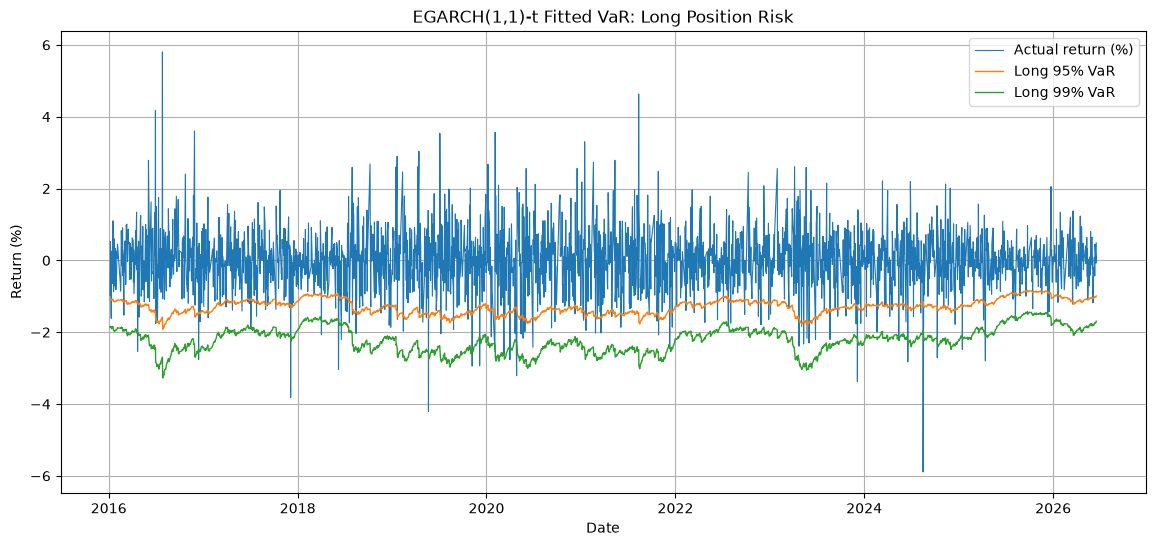

In [49]:
# ============================================================
# Cell 42：画收益率与 VaR 边界
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    var_usage["datetime"],
    var_usage["ret_pct"],
    linewidth=0.8,
    label="Actual return (%)"
)

plt.plot(
    var_usage["datetime"],
    var_usage["VaR_95_long_return_pct"],
    linewidth=1,
    label="Long 95% VaR"
)

plt.plot(
    var_usage["datetime"],
    var_usage["VaR_99_long_return_pct"],
    linewidth=1,
    label="Long 99% VaR"
)

plt.title("EGARCH(1,1)-t Fitted VaR: Long Position Risk")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.legend()
plt.grid(True)
plt.show()

In [50]:
# ============================================================
# Cell 43：构造波动率目标仓位缩放因子
# ============================================================
# EGARCH 的一个实际用途是仓位管理。
#
# 思路：
# 目标仓位 ∝ 目标波动率 / 当前预测波动率
#
# 例如：
# 如果当前波动率高于目标波动率，则仓位下降；
# 如果当前波动率低于目标波动率，则仓位上升。
#
# 这里使用历史中位数波动率作为目标波动率。
# 同时设置上下限，避免仓位因子过大或过小。

target_vol = egarch_usage["egarch_vol_pct"].median()

position_usage = egarch_usage.copy()
position_usage["target_vol_pct"] = target_vol

position_usage["raw_position_scale"] = (
    position_usage["target_vol_pct"] / position_usage["egarch_vol_pct"]
)

# 设置仓位缩放上下限
# 0.3：最低 30% 标准仓位
# 1.5：最高 150% 标准仓位
position_usage["position_scale_capped"] = position_usage["raw_position_scale"].clip(
    lower=0.30,
    upper=1.50
)

position_file = OUTPUT_DIR / "21_egarch11_t_position_scaling.csv"
position_usage.to_csv(position_file, index=False, encoding="utf-8-sig")

position_usage.tail()

,datetime,close,ret_pct,egarch_vol_pct,std_resid,egarch_vol_pctile,vol_state,target_vol_pct,raw_position_scale,position_scale_capped
2531,2026-06-10 16:00:00,"5,291.000000",-0.433758,0.661281,-0.655940,0.098975,low_vol,0.832291,1.258604,1.258604
2532,2026-06-11 16:00:00,"5,315.000000",0.452575,0.657403,0.688425,0.094637,low_vol,0.832291,1.266029,1.266029
2533,2026-06-14 16:00:00,"5,321.000000",0.112824,0.662791,0.170223,0.100552,low_vol,0.832291,1.255737,1.255737
2534,2026-06-15 16:00:00,"5,317.000000",-0.075202,0.654960,-0.114823,0.093060,low_vol,0.832291,1.270750,1.270750
2535,2026-06-16 16:00:00,"5,343.000000",0.487806,0.644482,0.756893,0.082413,low_vol,0.832291,1.291411,1.291411


In [51]:
# ============================================================
# Cell 44：查看最新仓位缩放建议
# ============================================================

latest_position = position_usage.iloc[-1]

print("========== 最新波动率仓位缩放参考 ==========")
print("日期：", latest_position["datetime"])
print("EGARCH 条件波动率 %：", round(latest_position["egarch_vol_pct"], 4))
print("目标波动率，即历史中位数 %：", round(latest_position["target_vol_pct"], 4))
print("原始仓位缩放因子：", round(latest_position["raw_position_scale"], 4))
print("截断后仓位缩放因子：", round(latest_position["position_scale_capped"], 4))
print("波动率状态：", latest_position["vol_state"])

if latest_position["position_scale_capped"] < 0.75:
    print("解释：当前波动率偏高，模型建议低于标准仓位。")
elif latest_position["position_scale_capped"] > 1.25:
    print("解释：当前波动率偏低，模型允许高于标准仓位，但仍需结合方向信号。")
else:
    print("解释：当前波动率接近常态，仓位可接近标准仓位。")

========== 最新波动率仓位缩放参考 ==========
日期： 2026-06-16 16:00:00
EGARCH 条件波动率 %： 0.6445
目标波动率，即历史中位数 %： 0.8323
原始仓位缩放因子： 1.2914
截断后仓位缩放因子： 1.2914
波动率状态： low_vol
解释：当前波动率偏低，模型允许高于标准仓位，但仍需结合方向信号。


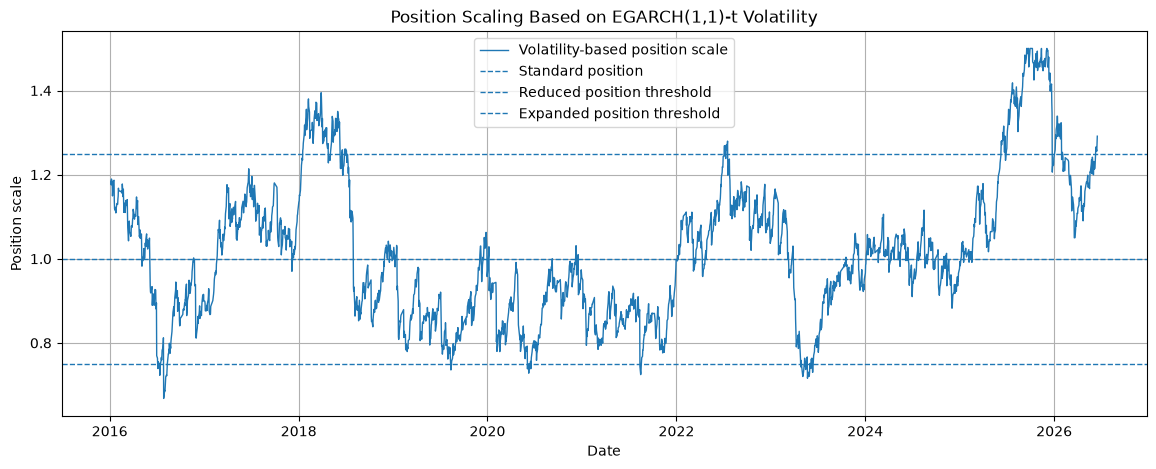

In [52]:
# ============================================================
# Cell 45：画仓位缩放因子
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    position_usage["datetime"],
    position_usage["position_scale_capped"],
    linewidth=1,
    label="Volatility-based position scale"
)

plt.axhline(1.0, linestyle="--", linewidth=1, label="Standard position")
plt.axhline(0.75, linestyle="--", linewidth=1, label="Reduced position threshold")
plt.axhline(1.25, linestyle="--", linewidth=1, label="Expanded position threshold")

plt.title("Position Scaling Based on EGARCH(1,1)-t Volatility")
plt.xlabel("Date")
plt.ylabel("Position scale")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
# ============================================================
# Cell 46：生成最终 EGARCH 使用报告表
# ============================================================

egarch_final_report = pd.DataFrame({
    "item": [
        "model",
        "aic",
        "bic",
        "mu",
        "omega",
        "alpha[1]",
        "gamma[1]",
        "beta[1]",
        "nu",
        "latest_date",
        "latest_close",
        "latest_return_pct",
        "latest_vol_pct",
        "latest_vol_percentile",
        "latest_vol_state",
        "next_day_forecast_vol_pct",
        "long_95_var_return_pct",
        "long_99_var_return_pct",
        "short_95_var_return_pct",
        "short_99_var_return_pct",
        "position_scale_capped"
    ],
    "value": [
        TARGET_MODEL_NAME,
        egarch_res.aic,
        egarch_res.bic,
        mu,
        omega,
        alpha1,
        gamma1,
        beta1,
        nu,
        latest_row["datetime"],
        latest_row["close"],
        latest_row["ret_pct"],
        latest_row["egarch_vol_pct"],
        latest_row["egarch_vol_pctile"],
        latest_row["vol_state"],
        next_vol,
        next_var_table.loc[0, "return_threshold_pct"],
        next_var_table.loc[1, "return_threshold_pct"],
        next_var_table.loc[2, "return_threshold_pct"],
        next_var_table.loc[3, "return_threshold_pct"],
        latest_position["position_scale_capped"]
    ]
})

final_report_file = OUTPUT_DIR / "22_egarch11_t_final_usage_report.csv"
egarch_final_report.to_csv(final_report_file, index=False, encoding="utf-8-sig")

egarch_final_report

,item,value
0,model,EGARCH11_t
1,aic,"5,969.511547"
2,bic,"6,004.541607"
3,mu,0.000002
4,omega,0.000804
5,alpha[1],0.057641
6,gamma[1],0.019412
7,beta[1],0.989908
8,nu,4.497111
9,latest_date,2026-06-16 16:00:00


In [54]:
# ============================================================
# Cell 47：保存 EGARCH 后续使用结果到 Excel
# ============================================================

egarch_excel_file = OUTPUT_DIR / "egarch11_t_usage_results.xlsx"

with pd.ExcelWriter(egarch_excel_file, engine="openpyxl") as writer:
    egarch_param_table.to_excel(writer, sheet_name="parameters", index=False)
    egarch_diag.to_excel(writer, sheet_name="residual_diagnostics", index=False)
    egarch_usage.to_excel(writer, sheet_name="volatility_usage", index=False)
    vol_state_summary.to_excel(writer, sheet_name="vol_state_summary", index=False)
    top_high_vol_days.to_excel(writer, sheet_name="top_high_vol_days", index=False)
    forecast_table.to_excel(writer, sheet_name="vol_forecast", index=False)
    next_var_table.to_excel(writer, sheet_name="next_day_var_return", index=False)
    price_var_table.to_excel(writer, sheet_name="next_day_var_price", index=False)
    var_usage.to_excel(writer, sheet_name="fitted_var_series", index=False)
    var_exception_summary.to_excel(writer, sheet_name="var_exception_summary", index=False)
    kupiec_results.to_excel(writer, sheet_name="kupiec_test", index=False)
    position_usage.to_excel(writer, sheet_name="position_scaling", index=False)
    egarch_final_report.to_excel(writer, sheet_name="final_report", index=False)

print("EGARCH 使用结果 Excel 已保存：")
print(egarch_excel_file.resolve())

EGARCH 使用结果 Excel 已保存：
/home/zilinm2/sr_traditional_volatility_output/egarch11_t_usage_results.xlsx


In [55]:
# ============================================================
# Cell 48：最终解释模板
# ============================================================
# 这一步自动生成一段可以放进报告里的解释。
# 后续你可以根据真实输出微调。

print("========== EGARCH(1,1)-t 使用结论模板 ==========\n")

print(f"本文在传统 GARCH 类模型比较后，选取 {TARGET_MODEL_NAME} 作为白糖主力合约收益率的波动率刻画模型。")

print("\n1. 模型含义")
print("EGARCH(1,1)-t 同时刻画三类特征：")
print("一是波动率聚集，即大波动后更容易继续大波动；")
print("二是非对称波动，即正负冲击对未来波动率影响可能不同；")
print("三是厚尾分布，即极端收益出现概率高于正态假设。")

print("\n2. 参数解释")
if gamma_p < 0.05:
    print(f"非对称项 gamma[1] = {gamma1:.6f}，且在 5% 水平下显著，说明白糖收益率存在非对称波动结构。")
else:
    print(f"非对称项 gamma[1] = {gamma1:.6f}，但在 5% 水平下不显著，非对称波动证据不强。")

if beta_p < 0.05:
    print(f"持续性项 beta[1] = {beta1:.6f}，且显著，说明白糖波动率具有持续性。")
else:
    print(f"持续性项 beta[1] = {beta1:.6f}，但显著性不足，需要谨慎解释。")

print(f"Student-t 自由度 nu = {nu:.6f}，用于刻画收益率厚尾。")

print("\n3. 当前波动率状态")
print(f"最新日期为 {latest_row['datetime']}，EGARCH 条件波动率为 {latest_row['egarch_vol_pct']:.4f}%，")
print(f"处于历史 {latest_row['egarch_vol_pctile'] * 100:.2f}% 分位，对应状态为 {latest_row['vol_state']}。")

print("\n4. 风险预测")
print(f"下一交易日预测波动率为 {next_vol:.4f}%。")
print("基于 EGARCH-t 分布，可以构造多头和空头的 95% / 99% VaR 边界。")

print("\n5. 仓位管理")
print(f"基于历史中位数波动率作为目标波动率，当前截断后的仓位缩放因子为 {latest_position['position_scale_capped']:.4f}。")
print("该因子只用于风险调整，不提供方向信号。")

print("\n6. 模型边界")
print("EGARCH(1,1)-t 是波动率模型，不是方向预测模型。")
print("它可以服务于 VaR、止损宽度、仓位缩放和风险状态识别，但不能单独判断白糖应该做多还是做空。")
print("后续若要进一步检验模型是否仍遗漏非线性波动率结构，可接入 Hong-Lee generalized spectral test。")

========== EGARCH(1,1)-t 使用结论模板 ==========

本文在传统 GARCH 类模型比较后，选取 EGARCH11_t 作为白糖主力合约收益率的波动率刻画模型。

1. 模型含义
EGARCH(1,1)-t 同时刻画三类特征：
一是波动率聚集，即大波动后更容易继续大波动；
二是非对称波动，即正负冲击对未来波动率影响可能不同；
三是厚尾分布，即极端收益出现概率高于正态假设。

2. 参数解释
非对称项 gamma[1] = 0.019412，但在 5% 水平下不显著，非对称波动证据不强。
持续性项 beta[1] = 0.989908，且显著，说明白糖波动率具有持续性。
Student-t 自由度 nu = 4.497111，用于刻画收益率厚尾。

3. 当前波动率状态
最新日期为 2026-06-16 16:00:00，EGARCH 条件波动率为 0.6445%，
处于历史 8.24% 分位，对应状态为 low_vol。

4. 风险预测
下一交易日预测波动率为 0.6516%。
基于 EGARCH-t 分布，可以构造多头和空头的 95% / 99% VaR 边界。

5. 仓位管理
基于历史中位数波动率作为目标波动率，当前截断后的仓位缩放因子为 1.2914。
该因子只用于风险调整，不提供方向信号。

6. 模型边界
EGARCH(1,1)-t 是波动率模型，不是方向预测模型。
它可以服务于 VaR、止损宽度、仓位缩放和风险状态识别，但不能单独判断白糖应该做多还是做空。
后续若要进一步检验模型是否仍遗漏非线性波动率结构，可接入 Hong-Lee generalized spectral test。
